# CICEV2023 DDoS Attack Detection

## Leakage-Aware Feature Engineering and Comparative Modeling

### Research Objective

This study investigates machine-learning and deep-learning approaches for detecting DDoS attacks in Electric Vehicle Charging Infrastructure using the CICEV2023 dataset.

The experimental framework focuses on:

1. Dataset characterization
2. Class imbalance analysis
3. Data leakage investigation
4. Leakage-aware feature engineering
5. Session-level train-test separation
6. Feature selection
7. Random Forest modeling
8. CNN modeling
9. Attention-based modeling
10. Threshold optimization
11. Generalization analysis
12. Final model comparison

### Research Principle

Each methodological transition is documented together with its motivation, implementation, experimental observation, and resulting decision to maintain research traceability.

In [1]:
# ============================================================
# CELL 1 — SETUP & PATH CONFIGURATION
# ============================================================
# PURPOSE:
# Import required libraries and define the folder structure for
# locating the DDoS attack-profiling dataset (raw and processed
# data directories) under the selected scenario configuration
# (Correct_ID, Random_CS_Off, Gaussian_Off, Attack).
#
# WHY:
# All downstream cells depend on these paths existing; verifying
# them early avoids confusing file-not-found errors later in the
# pipeline.
# ============================================================

import os
import json
import glob
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

BASE_DIR = "/kaggle/input/datasets/agungpambudi/secure-intrusion-detection-ddos-attacks-profiling/ddos-attacks-profiling"
if not os.path.exists(BASE_DIR):
    BASE_DIR = "ddos-attacks-profiling"

RAW_DIR  = os.path.join(BASE_DIR, "Raw_Data")
PROC_DIR = os.path.join(BASE_DIR, "Processed_Data")

ID_SCENARIO = "Correct_ID"
RANDOM_CS   = "Random_CS_Off"
GAUSSIAN    = "Gaussian_Off"
TRAFFIC     = "Attack"

scenario_path      = os.path.join(RAW_DIR, ID_SCENARIO, RANDOM_CS, GAUSSIAN, TRAFFIC)
proc_scenario_path = os.path.join(PROC_DIR, ID_SCENARIO, RANDOM_CS, GAUSSIAN)

print("Raw exists:", os.path.exists(RAW_DIR))
print("Scenario exists:", os.path.exists(scenario_path))

Raw exists: True
Scenario exists: True


In [2]:
# ============================================================
# CELL 2 — BUILD EVENT TABLE
# ============================================================
# PURPOSE:
# Merge the raw per-scenario CSV files (authentication results, EV
# installation, CS ID/PID mapping, CS installation, and ACN
# charging summaries) into a single unified event_table keyed on
# Session ID / CS ID.
#
# WHY:
# The individual source files only capture one aspect of a
# charging session each; a single merged table is needed before
# any leakage analysis or feature engineering can be performed.
# ============================================================

auth_df = pd.read_csv(os.path.join(scenario_path, "authentication_results.csv"))
ev_install_df = pd.read_csv(os.path.join(scenario_path, "ev_installation.csv"))

event_table = auth_df.merge(
    ev_install_df,
    on="Session ID",
    how="left",
    suffixes=("", "_ev")
)

if "CS Id" in event_table.columns:
    event_table = event_table.drop(columns=["CS Id"])

if "Installation_ev" in event_table.columns:
    event_table = event_table.rename(
        columns={"Installation_ev": "EV_Installation_Flag"}
    )

cs_id_pid_df = pd.read_csv(
    os.path.join(scenario_path, "cs_id_pid.csv")
)
event_table = event_table.merge(
    cs_id_pid_df,
    on="CS ID",
    how="left"
)

cs_install_df = pd.read_csv(
    os.path.join(scenario_path, "cs_installation.csv")
)
cs_install_df["CS_Was_Installed"] = True

event_table = event_table.merge(
    cs_install_df,
    on="CS ID",
    how="left"
)

event_table["CS_Was_Installed"] = (
    event_table["CS_Was_Installed"].fillna(False)
)

acn_df = pd.read_csv(
    os.path.join(scenario_path, "acn_data.csv")
)

acn_station_summary = (
    acn_df.groupby("stationID")
    .agg(
        ACN_avg_kWhDelivered=("kWhDelivered", "mean"),
        ACN_total_sessions=("sessionID", "count"),
    )
    .reset_index()
    .rename(columns={"stationID": "CS ID"})
)

event_table = event_table.merge(
    acn_station_summary,
    on="CS ID",
    how="left"
)

event_table["ID_Scenario"] = ID_SCENARIO
event_table["Random_CS_Config"] = RANDOM_CS
event_table["Gaussian_Config"] = GAUSSIAN
event_table["Traffic_Type_Folder"] = TRAFFIC

print("✅ event_table ready!")
print("Shape:", event_table.shape)
display(event_table.head())

✅ event_table ready!
Shape: (111284, 19)


,Session ID,CS ID,Timestamp,Authentication,Installation,Type,Date_Time,Process Order,HEX EV ID,HEX Key,EV_Installation_Flag,CS PID,CS_Was_Installed,ACN_avg_kWhDelivered,ACN_total_sessions,ID_Scenario,Random_CS_Config,Gaussian_Config,Traffic_Type_Folder
0,5e44a6aef9af8b20e5250354,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:45.699746,654,0ca957b617d5c757cc251016837f11f0d76acfafaae4a5...,e7066c74355959b3dd38dcf5dc9fcf6fc84f47cd94989a...,True,1362420,True,7.032083,12,Correct_ID,Random_CS_Off,Gaussian_Off,Attack
1,5e7e9a9bf9af8b1be143ed74,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:45.746531,660,edbff329936820afcb0043988cbe312919a67ebfc24bcb...,69516d6f79eb91b06658862d7bffe4061177cfebcc5cad...,True,1362420,True,7.032083,12,Correct_ID,Random_CS_Off,Gaussian_Off,Attack
2,5e095332f9af8b6b70d5c4a6,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:45.814037,652,f84ef719852a46addf0cd9a3bd4c0063ab28d6fb0b0567...,62b74153df4d41659dd2131838d74d8d233141be6a7350...,True,1362420,True,7.032083,12,Correct_ID,Random_CS_Off,Gaussian_Off,Attack
3,5e45f835f9af8b24b31daa6b,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:45.884205,656,42dea0cdc5186dc6fec759131fb1d1a86489a0bd5277f6...,bbef939cc8b5da0402fef30c06e0b1927947f07d7241d0...,True,1362420,True,7.032083,12,Correct_ID,Random_CS_Off,Gaussian_Off,Attack
4,5eb74b0bf9af8b3dfb27c4b4,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:46.031090,661,a4ee17f07e6e0497b7b10d06ab766447b952d4ecc2c2dc...,04befebac1bdb907fb92a54daa75d7d4ecb65158ca0bfd...,True,1362420,True,7.032083,12,Correct_ID,Random_CS_Off,Gaussian_Off,Attack


In [3]:
# ============================================================
# CELL 3 — DATA LEAKAGE AUDIT
# ============================================================
# PURPOSE:
# Inspect the merged event_table for its label distribution and
# compute the absolute correlation of every numeric feature with
# the Label column.
#
# WHY:
# Features with unusually high correlation to the target are an
# early warning sign of data leakage — columns that indirectly
# encode the answer instead of describing real traffic or charging
# behavior.
# ============================================================

# Create ML dataframe
df_ml = event_table.copy()

print("=" * 70)
print("DATA LEAKAGE AUDIT")
print("=" * 70)

print("\nDataset shape:")
print(df_ml.shape)

print("\nAvailable columns:")
print(df_ml.columns.tolist())

# ------------------------------------------------------------
# Check whether Label exists
# ------------------------------------------------------------
if "Label" not in df_ml.columns:
    print("\n⚠️ WARNING: 'Label' column is not present in event_table.")
    print("Skipping label distribution and correlation analysis.")
    print("Available columns are shown above.")

else:
    print("\nLabel distribution:")
    print(df_ml["Label"].value_counts())
    print(df_ml["Label"].value_counts(normalize=True))

    print("\n" + "=" * 70)
    print("FEATURE vs LABEL CORRELATION")
    print("=" * 70)

    numeric_features = df_ml.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    if "Label" in numeric_features:
        numeric_features.remove("Label")

    if len(numeric_features) > 0:
        correlations = (
            df_ml[numeric_features + ["Label"]]
            .corr()["Label"]
            .drop("Label")
            .abs()
            .sort_values(ascending=False)
        )

        display(
            correlations.to_frame(
                name="Absolute Correlation with Label"
            )
        )

        print("\nTop suspicious features:")

        for feature, corr in correlations.head(10).items():
            print(f"{feature:35s} : {corr:.4f}")

    else:
        print("⚠️ No numeric features available for correlation analysis.")

DATA LEAKAGE AUDIT

Dataset shape:
(111284, 19)

Available columns:
['Session ID', 'CS ID', 'Timestamp', 'Authentication', 'Installation', 'Type', 'Date_Time', 'Process Order', 'HEX EV ID', 'HEX Key', 'EV_Installation_Flag', 'CS PID', 'CS_Was_Installed', 'ACN_avg_kWhDelivered', 'ACN_total_sessions', 'ID_Scenario', 'Random_CS_Config', 'Gaussian_Config', 'Traffic_Type_Folder']

⚠️ WARNING: 'Label' column is not present in event_table.
Skipping label distribution and correlation analysis.
Available columns are shown above.


In [4]:
# ============================================================
# CELL 4 — LABEL CONSISTENCY PER SESSION
# ============================================================
# PURPOSE:
# Count how many Session IDs contain more than one distinct Type
# value (i.e. a session that is partly Normal and partly Attack).
#
# WHY:
# Mixed-label sessions would make a session-level group split
# ambiguous, so this check confirms whether Session ID is a safe
# grouping key.
# ============================================================

print("=" * 70)
print("LABEL CONSISTENCY PER SESSION")
print("=" * 70)

session_label_check = (
    event_table
    .groupby("Session ID")["Type"]
    .nunique()
)

print(
    "Sessions containing BOTH normal and attack labels:"
)

mixed_sessions = (
    session_label_check > 1
).sum()

print(
    mixed_sessions
)

print(
    "\nTotal unique sessions:"
)

print(
    len(session_label_check)
)

print(
    "\nPercentage of mixed sessions:"
)

print(
    mixed_sessions /
    len(session_label_check) *
    100
)

LABEL CONSISTENCY PER SESSION
Sessions containing BOTH normal and attack labels:
53

Total unique sessions:
5284

Percentage of mixed sessions:
1.0030280090840271


In [5]:
# ============================================================
# CELL 5 — LEAKAGE-AWARE FEATURE ENGINEERING
# ============================================================
# PURPOSE:
# Build the modeling dataframe df_ml from the raw event_table:
# extract time-based features from Date_Time, encode the binary
# target Label, drop leakage-prone / identifier / scenario
# columns, keep only numeric columns, and impute remaining missing
# values with the column median.
#
# WHY:
# This produces the first clean, leakage-controlled feature set
# that can be safely used to train a baseline model without the
# model learning shortcuts from Authentication/Installation or
# from scenario metadata.
# ============================================================

print("=" * 70)
print("FEATURE ENGINEERING — LEAKAGE-AWARE VERSION")
print("=" * 70)

df_ml = event_table.copy()

# ------------------------------------------------------------
# 1. Convert Date_Time
# ------------------------------------------------------------
df_ml["Date_Time"] = pd.to_datetime(
    df_ml["Date_Time"],
    errors="coerce"
)

# ------------------------------------------------------------
# 2. Time-based features
# ------------------------------------------------------------
df_ml["hour_of_day"] = df_ml["Date_Time"].dt.hour
df_ml["day_of_week"] = df_ml["Date_Time"].dt.dayofweek
df_ml["minute"] = df_ml["Date_Time"].dt.minute
df_ml["day_of_month"] = df_ml["Date_Time"].dt.day
df_ml["month"] = df_ml["Date_Time"].dt.month

# Night indicator
df_ml["is_night"] = (
    (df_ml["hour_of_day"] < 6) |
    (df_ml["hour_of_day"] >= 22)
).astype(int)

# Weekend indicator
df_ml["is_weekend"] = (
    df_ml["day_of_week"] >= 5
).astype(int)

# Business hours
df_ml["is_business_hour"] = (
    (df_ml["hour_of_day"] >= 9) &
    (df_ml["hour_of_day"] < 18) &
    (df_ml["is_weekend"] == 0)
).astype(int)

# Peak-hour indicator
df_ml["is_peak_hour"] = (
    df_ml["hour_of_day"].isin([7, 8, 9, 17, 18, 19])
).astype(int)

# ------------------------------------------------------------
# 3. Cyclic time encoding
# ------------------------------------------------------------

df_ml["hour_sin"] = np.sin(
    2 * np.pi * df_ml["hour_of_day"] / 24
)

df_ml["hour_cos"] = np.cos(
    2 * np.pi * df_ml["hour_of_day"] / 24
)

df_ml["day_sin"] = np.sin(
    2 * np.pi * df_ml["day_of_week"] / 7
)

df_ml["day_cos"] = np.cos(
    2 * np.pi * df_ml["day_of_week"] / 7
)

# ------------------------------------------------------------
# 4. Target
# ------------------------------------------------------------

df_ml["Label"] = (
    df_ml["Type"].astype(str).str.lower() == "attack"
).astype(int)

# ------------------------------------------------------------
# 5. Encode useful categorical/binary features
# ------------------------------------------------------------

# Timestamp: fresh = 1
if "Timestamp" in df_ml.columns:
    df_ml["Timestamp"] = (
        df_ml["Timestamp"].astype(str).str.lower() == "fresh"
    ).astype(int)

# NOTE:
# Authentication and Installation are intentionally NOT used.
# Leakage analysis showed they almost directly determine Label.

# ------------------------------------------------------------
# 6. Numeric conversions
# ------------------------------------------------------------

if "CS PID" in df_ml.columns:
    df_ml["CS PID"] = pd.to_numeric(
        df_ml["CS PID"],
        errors="coerce"
    )

if "Process Order" in df_ml.columns:
    df_ml["Process Order"] = pd.to_numeric(
        df_ml["Process Order"],
        errors="coerce"
    )

# ------------------------------------------------------------
# 7. Process-derived features
# ------------------------------------------------------------

if "Process Order" in df_ml.columns:

    df_ml["Process_Order_Squared"] = (
        df_ml["Process Order"] ** 2
    )

    df_ml["Process_Order_Log"] = np.log1p(
        np.abs(df_ml["Process Order"])
    )

    df_ml["Process_Order_Cubic"] = (
        df_ml["Process Order"] ** 3
    )

# ------------------------------------------------------------
# 8. Remove leakage / identifier / redundant columns
# ------------------------------------------------------------

drop_cols = [
    # Target source
    "Type",

    # Raw datetime after feature extraction
    "Date_Time",

    # Identifiers
    "Session ID",
    "HEX EV ID",
    "HEX Key",
    "CS ID",

    # Scenario metadata
    "ID_Scenario",
    "Random_CS_Config",
    "Gaussian_Config",
    "Traffic_Type_Folder",

    # Leakage-prone features
    "Authentication",
    "Installation",

    # Leakage-prone interactions
    "Auth_Process_Interaction",
    "Install_Process_Interaction",
    "Auth_Install_Interaction",

    # Installation-related flags
    "EV_Installation_Flag",
    "CS_Was_Installed"
]

df_ml = df_ml.drop(
    columns=[
        c for c in drop_cols
        if c in df_ml.columns
    ],
    errors="ignore"
)

# ------------------------------------------------------------
# 9. Keep only numeric columns
# ------------------------------------------------------------

non_numeric = df_ml.select_dtypes(
    exclude=[np.number]
).columns.tolist()

if non_numeric:
    print("\nDropping non-numeric columns:")
    print(non_numeric)

    df_ml = df_ml.drop(
        columns=non_numeric
    )

# ------------------------------------------------------------
# 10. Handle NaN / Inf
# ------------------------------------------------------------

df_ml = df_ml.replace(
    [np.inf, -np.inf],
    np.nan
)

for col in df_ml.columns:

    if col == "Label":
        continue

    if df_ml[col].isnull().sum() > 0:

        median_value = df_ml[col].median()

        df_ml[col] = df_ml[col].fillna(
            median_value
        )

# ------------------------------------------------------------
# 11. Final feature list
# ------------------------------------------------------------

feature_names = [
    c for c in df_ml.columns
    if c != "Label"
]

print("\n" + "=" * 70)
print("FINAL FEATURE SET")
print("=" * 70)

for i, feature in enumerate(
    feature_names,
    start=1
):
    print(
        f"{i:2d}. {feature}"
    )

print(
    f"\nTotal features: {len(feature_names)}"
)

print("\nLabel distribution:")
print(
    df_ml["Label"].value_counts()
)

print("\nLabel percentage:")
print(
    df_ml["Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nFinal shape:")
print(
    df_ml.shape
)

display(
    df_ml.head()
)

FEATURE ENGINEERING — LEAKAGE-AWARE VERSION

FINAL FEATURE SET
 1. Timestamp
 2. Process Order
 3. CS PID
 4. ACN_avg_kWhDelivered
 5. ACN_total_sessions
 6. hour_of_day
 7. day_of_week
 8. minute
 9. day_of_month
10. month
11. is_night
12. is_weekend
13. is_business_hour
14. is_peak_hour
15. hour_sin
16. hour_cos
17. day_sin
18. day_cos
19. Process_Order_Squared
20. Process_Order_Log
21. Process_Order_Cubic

Total features: 21

Label distribution:
Label
1    106000
0      5284
Name: count, dtype: int64

Label percentage:
Label
1    95.25
0     4.75
Name: proportion, dtype: float64

Final shape:
(111284, 22)


,Timestamp,Process Order,CS PID,ACN_avg_kWhDelivered,ACN_total_sessions,hour_of_day,day_of_week,minute,day_of_month,month,...,is_business_hour,is_peak_hour,hour_sin,hour_cos,day_sin,day_cos,Label,Process_Order_Squared,Process_Order_Log,Process_Order_Cubic
0,1,654,1362420,7.032083,12,0,1,42,17,1,...,0,0,0.0,1.0,0.781831,0.62349,0,427716,6.484635,279726264
1,1,660,1362420,7.032083,12,0,1,42,17,1,...,0,0,0.0,1.0,0.781831,0.62349,0,435600,6.493754,287496000
2,1,652,1362420,7.032083,12,0,1,42,17,1,...,0,0,0.0,1.0,0.781831,0.62349,0,425104,6.481577,277167808
3,1,656,1362420,7.032083,12,0,1,42,17,1,...,0,0,0.0,1.0,0.781831,0.62349,0,430336,6.487684,282300416
4,1,661,1362420,7.032083,12,0,1,42,17,1,...,0,0,0.0,1.0,0.781831,0.62349,0,436921,6.495266,288804781


In [6]:
# ============================================================
# CELL 6 — GROUP-BASED TRAIN/TEST SPLIT + SCALING
# ============================================================
# PURPOSE:
# Split df_ml into train/test sets using GroupShuffleSplit on
# Session ID (80/20), verify there is no session overlap between
# the two sets, then fit a StandardScaler on the training data
# only and apply it to both sets.
#
# WHY:
# A random row-level split would let the same session leak into
# both train and test; grouping by Session ID prevents that, and
# fitting the scaler on training data only avoids leaking test-set
# statistics into training.
# ============================================================

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("GROUP-BASED TRAIN / TEST SPLIT")
print("=" * 70)

# ------------------------------------------------------------
# Features and target
# ------------------------------------------------------------

X = df_ml.drop(columns=["Label"]).copy()
y = df_ml["Label"].copy()

feature_names = X.columns.tolist()

# ------------------------------------------------------------
# IMPORTANT:
# Use Session ID from the original event_table as group.
# This prevents samples from the same session appearing
# in both training and testing sets.
# ------------------------------------------------------------

groups = event_table["Session ID"].values

print("Total samples :", len(X))
print("Unique groups :", len(np.unique(groups)))
print("Total features:", len(feature_names))

# ------------------------------------------------------------
# Group-based 80/20 split
# ------------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train_raw = X.iloc[train_idx].copy()
X_test_raw  = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test  = y.iloc[test_idx].copy()

groups_train = groups[train_idx]
groups_test  = groups[test_idx]

# ------------------------------------------------------------
# Verify NO group/session overlap
# ------------------------------------------------------------

train_groups = set(groups_train)
test_groups  = set(groups_test)

overlap = train_groups.intersection(test_groups)

print("\nSession overlap:", len(overlap))

if len(overlap) == 0:
    print("✅ No session leakage!")
else:
    print("⚠️ WARNING: Session leakage detected!")

# ------------------------------------------------------------
# Scale features
# IMPORTANT:
# Fit scaler ONLY on training data.
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# ------------------------------------------------------------
# Label distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAIN / TEST SHAPES")
print("=" * 70)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTrain labels:")
print(
    pd.Series(y_train).value_counts().sort_index()
)

print("\nTest labels:")
print(
    pd.Series(y_test).value_counts().sort_index()
)

print("\nTrain label percentages:")
print(
    pd.Series(y_train)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTest label percentages:")
print(
    pd.Series(y_test)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n✅ Group-based split and scaling complete!")

GROUP-BASED TRAIN / TEST SPLIT
Total samples : 111284
Unique groups : 5284
Total features: 21

Session overlap: 0
✅ No session leakage!

TRAIN / TEST SHAPES
X_train: (94227, 21)
X_test : (17057, 21)

Train labels:
Label
0     4227
1    90000
Name: count, dtype: int64

Test labels:
Label
0     1057
1    16000
Name: count, dtype: int64

Train label percentages:
Label
1    95.51
0     4.49
Name: proportion, dtype: float64

Test label percentages:
Label
1    93.8
0     6.2
Name: proportion, dtype: float64

✅ Group-based split and scaling complete!


RANDOM FOREST BASELINE — LEAKAGE-AWARE DATA

Training Random Forest...
✅ Training complete!

RANDOM FOREST RESULTS
Accuracy  : 68.49%
Precision : 0.9989
Recall    : 0.6648
F1 Score  : 0.7983
ROC-AUC   : 0.9528

Classification Report:
              precision    recall  f1-score   support

      Normal       0.16      0.99      0.28      1057
      Attack       1.00      0.66      0.80     16000

    accuracy                           0.68     17057
   macro avg       0.58      0.83      0.54     17057
weighted avg       0.95      0.68      0.77     17057


Confusion Matrix:
[[ 1045    12]
 [ 5363 10637]]


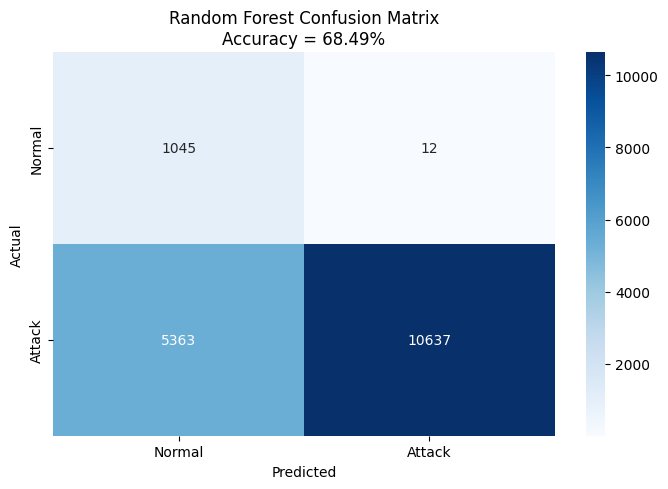


TRAIN vs TEST
Train Accuracy : 99.99%
Test Accuracy  : 68.49%
Difference     : 31.50%

FEATURE IMPORTANCE
minute                   0.404174
Process_Order_Cubic      0.116458
Process_Order_Log        0.114433
Process Order            0.109877
Process_Order_Squared    0.102379
ACN_total_sessions       0.079086
ACN_avg_kWhDelivered     0.045082
CS PID                   0.028384
Timestamp                0.000127
month                    0.000000
hour_of_day              0.000000
day_of_week              0.000000
day_of_month             0.000000
is_business_hour         0.000000
is_weekend               0.000000
is_night                 0.000000
is_peak_hour             0.000000
day_sin                  0.000000
hour_cos                 0.000000
hour_sin                 0.000000
day_cos                  0.000000
dtype: float64


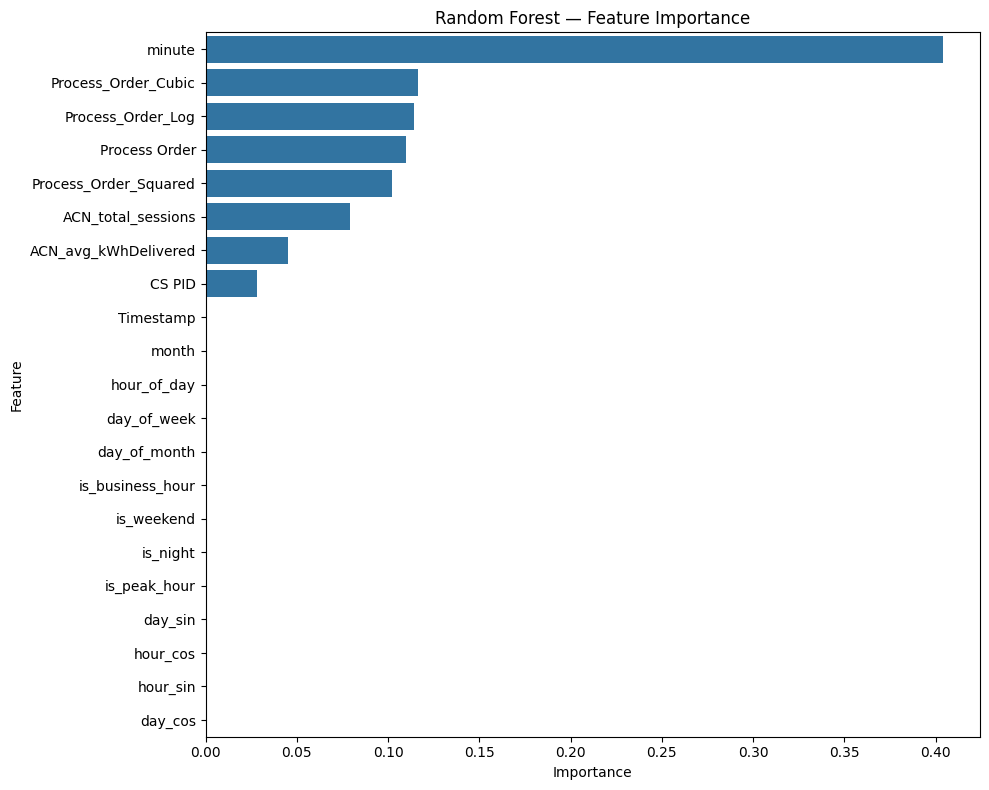


✅ Random Forest baseline complete!


In [7]:
# ============================================================
# CELL 7 — RANDOM FOREST BASELINE
# ============================================================
# PURPOSE:
# Train a baseline RandomForestClassifier on the leakage-aware
# features, evaluate it on the held-out test set (accuracy,
# precision, recall, F1, ROC-AUC, confusion matrix), and inspect
# feature importances.
#
# WHY:
# Establishes a reference performance level with a fast, robust
# model before any advanced feature engineering or deep-learning
# models are introduced.
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("RANDOM FOREST BASELINE — LEAKAGE-AWARE DATA")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create Random Forest
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt"
)

# ------------------------------------------------------------
# 2. Train
# ------------------------------------------------------------

print("\nTraining Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("✅ Training complete!")

# ------------------------------------------------------------
# 3. Predictions
# ------------------------------------------------------------

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 4. Metrics
# ------------------------------------------------------------

rf_acc = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

# ------------------------------------------------------------
# 5. Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RANDOM FOREST RESULTS")
print("=" * 70)

print(f"Accuracy  : {rf_acc * 100:.2f}%")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")

# ------------------------------------------------------------
# 6. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 7. Confusion Matrix
# ------------------------------------------------------------

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("\nConfusion Matrix:")
print(cm_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.title(
    f"Random Forest Confusion Matrix\nAccuracy = {rf_acc * 100:.2f}%"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Train vs Test Accuracy
# ------------------------------------------------------------

y_train_pred_rf = rf_model.predict(X_train)

rf_train_acc = accuracy_score(
    y_train,
    y_train_pred_rf
)

print("\n" + "=" * 70)
print("TRAIN vs TEST")
print("=" * 70)

print(f"Train Accuracy : {rf_train_acc * 100:.2f}%")
print(f"Test Accuracy  : {rf_acc * 100:.2f}%")
print(
    f"Difference     : {(rf_train_acc - rf_acc) * 100:.2f}%"
)

# ------------------------------------------------------------
# 9. Feature Importance
# ------------------------------------------------------------

importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

print(importances)

# ------------------------------------------------------------
# 10. Feature importance plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

sns.barplot(
    x=importances.values,
    y=importances.index
)

plt.title(
    "Random Forest — Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

print("\n✅ Random Forest baseline complete!")

In [8]:
# ============================================================
# CELL 8 — ADVANCED LEGITIMATE FEATURE ENGINEERING
# ============================================================
# PURPOSE:
# Build a second, richer feature set (df_adv) from the raw
# event_table — extended time-of-day features, cyclic encodings,
# process-order transforms, and ACN charging-behavior features —
# while still excluding all leakage-prone and identifier columns.
#
# WHY:
# The baseline feature set from Cell 3 is intentionally minimal;
# this cell tests whether additional, legitimately observable
# behavioral features can improve performance without
# reintroducing leakage.
# ============================================================

print("=" * 70)
print("ADVANCED FEATURE ENGINEERING")
print("=" * 70)

# Work from the original event table
df_adv = event_table.copy()

# ------------------------------------------------------------
# 1. Date-Time features
# ------------------------------------------------------------

df_adv["Date_Time"] = pd.to_datetime(
    df_adv["Date_Time"],
    errors="coerce"
)

df_adv["hour"] = df_adv["Date_Time"].dt.hour
df_adv["minute"] = df_adv["Date_Time"].dt.minute
df_adv["day_of_week"] = df_adv["Date_Time"].dt.dayofweek
df_adv["day_of_month"] = df_adv["Date_Time"].dt.day
df_adv["month"] = df_adv["Date_Time"].dt.month

# ------------------------------------------------------------
# 2. More temporal behavior features
# ------------------------------------------------------------

df_adv["hour_minute"] = (
    df_adv["hour"] * 60 +
    df_adv["minute"]
)

df_adv["is_morning"] = (
    (df_adv["hour"] >= 6) &
    (df_adv["hour"] < 12)
).astype(int)

df_adv["is_afternoon"] = (
    (df_adv["hour"] >= 12) &
    (df_adv["hour"] < 18)
).astype(int)

df_adv["is_evening"] = (
    (df_adv["hour"] >= 18) &
    (df_adv["hour"] < 22)
).astype(int)

df_adv["is_night"] = (
    (df_adv["hour"] < 6) |
    (df_adv["hour"] >= 22)
).astype(int)

df_adv["is_weekend"] = (
    df_adv["day_of_week"] >= 5
).astype(int)

# ------------------------------------------------------------
# 3. Cyclic time features
# ------------------------------------------------------------

df_adv["hour_sin"] = np.sin(
    2 * np.pi * df_adv["hour"] / 24
)

df_adv["hour_cos"] = np.cos(
    2 * np.pi * df_adv["hour"] / 24
)

df_adv["minute_sin"] = np.sin(
    2 * np.pi * df_adv["minute"] / 60
)

df_adv["minute_cos"] = np.cos(
    2 * np.pi * df_adv["minute"] / 60
)

df_adv["day_sin"] = np.sin(
    2 * np.pi * df_adv["day_of_week"] / 7
)

df_adv["day_cos"] = np.cos(
    2 * np.pi * df_adv["day_of_week"] / 7
)

# ------------------------------------------------------------
# 4. Process-order features
# ------------------------------------------------------------

df_adv["Process Order"] = pd.to_numeric(
    df_adv["Process Order"],
    errors="coerce"
)

df_adv["Process_Order_Squared"] = (
    df_adv["Process Order"] ** 2
)

df_adv["Process_Order_Cubic"] = (
    df_adv["Process Order"] ** 3
)

df_adv["Process_Order_Log"] = np.log1p(
    np.abs(df_adv["Process Order"])
)

# Process order groups
df_adv["Process_Order_High"] = (
    df_adv["Process Order"] >
    df_adv["Process Order"].median()
).astype(int)

# ------------------------------------------------------------
# 5. ACN charging behavior
# ------------------------------------------------------------

df_adv["ACN_avg_kWhDelivered"] = pd.to_numeric(
    df_adv["ACN_avg_kWhDelivered"],
    errors="coerce"
)

df_adv["ACN_total_sessions"] = pd.to_numeric(
    df_adv["ACN_total_sessions"],
    errors="coerce"
)

# Energy per session
df_adv["ACN_energy_per_session"] = (
    df_adv["ACN_avg_kWhDelivered"] /
    (df_adv["ACN_total_sessions"] + 1)
)

# Log transformation of session count
df_adv["ACN_sessions_log"] = np.log1p(
    df_adv["ACN_total_sessions"]
)

# ------------------------------------------------------------
# 6. CS PID transformation
# ------------------------------------------------------------

df_adv["CS PID"] = pd.to_numeric(
    df_adv["CS PID"],
    errors="coerce"
)

df_adv["CS_PID_Log"] = np.log1p(
    np.abs(df_adv["CS PID"])
)

# ------------------------------------------------------------
# 7. Target
# ------------------------------------------------------------

df_adv["Label"] = (
    df_adv["Type"]
    .astype(str)
    .str.lower()
    .eq("attack")
).astype(int)

# ------------------------------------------------------------
# 8. Remove leakage / identifiers
# ------------------------------------------------------------

remove_cols = [
    "Type",
    "Date_Time",

    # identifiers
    "Session ID",
    "HEX EV ID",
    "HEX Key",
    "CS ID",

    # scenario metadata
    "ID_Scenario",
    "Random_CS_Config",
    "Gaussian_Config",
    "Traffic_Type_Folder",

    # confirmed leakage
    "Authentication",
    "Installation",
    "Auth_Process_Interaction",
    "Install_Process_Interaction",
    "Auth_Install_Interaction",

    # installation flags
    "EV_Installation_Flag",
    "CS_Was_Installed"
]

df_adv = df_adv.drop(
    columns=[
        c for c in remove_cols
        if c in df_adv.columns
    ],
    errors="ignore"
)

# ------------------------------------------------------------
# 9. Keep numeric features only
# ------------------------------------------------------------

non_numeric = df_adv.select_dtypes(
    exclude=[np.number]
).columns.tolist()

if non_numeric:
    print("\nRemoving non-numeric columns:")
    print(non_numeric)

    df_adv = df_adv.drop(
        columns=non_numeric
    )

# ------------------------------------------------------------
# 10. Clean infinite / missing values
# ------------------------------------------------------------

df_adv = df_adv.replace(
    [np.inf, -np.inf],
    np.nan
)

for col in df_adv.columns:

    if col == "Label":
        continue

    if df_adv[col].isnull().sum() > 0:

        df_adv[col] = df_adv[col].fillna(
            df_adv[col].median()
        )

# ------------------------------------------------------------
# 11. Final feature list
# ------------------------------------------------------------

advanced_features = [
    c for c in df_adv.columns
    if c != "Label"
]

print("\n" + "=" * 70)
print("ADVANCED FEATURE SET")
print("=" * 70)

for i, feature in enumerate(
    advanced_features,
    1
):
    print(f"{i:2d}. {feature}")

print(
    f"\nTotal features: {len(advanced_features)}"
)

print("\nLabel distribution:")
print(
    df_adv["Label"].value_counts()
)

print("\nShape:")
print(
    df_adv.shape
)

display(
    df_adv.head()
)

print("\n✅ Advanced feature engineering complete!")

ADVANCED FEATURE ENGINEERING

Removing non-numeric columns:
['Timestamp']

ADVANCED FEATURE SET
 1. Process Order
 2. CS PID
 3. ACN_avg_kWhDelivered
 4. ACN_total_sessions
 5. hour
 6. minute
 7. day_of_week
 8. day_of_month
 9. month
10. hour_minute
11. is_morning
12. is_afternoon
13. is_evening
14. is_night
15. is_weekend
16. hour_sin
17. hour_cos
18. minute_sin
19. minute_cos
20. day_sin
21. day_cos
22. Process_Order_Squared
23. Process_Order_Cubic
24. Process_Order_Log
25. Process_Order_High
26. ACN_energy_per_session
27. ACN_sessions_log
28. CS_PID_Log

Total features: 28

Label distribution:
Label
1    106000
0      5284
Name: count, dtype: int64

Shape:
(111284, 29)


,Process Order,CS PID,ACN_avg_kWhDelivered,ACN_total_sessions,hour,minute,day_of_week,day_of_month,month,hour_minute,...,day_sin,day_cos,Process_Order_Squared,Process_Order_Cubic,Process_Order_Log,Process_Order_High,ACN_energy_per_session,ACN_sessions_log,CS_PID_Log,Label
0,654,1362420,7.032083,12,0,42,1,17,1,42,...,0.781831,0.62349,427716,279726264,6.484635,0,0.540929,2.564949,14.124774,0
1,660,1362420,7.032083,12,0,42,1,17,1,42,...,0.781831,0.62349,435600,287496000,6.493754,0,0.540929,2.564949,14.124774,0
2,652,1362420,7.032083,12,0,42,1,17,1,42,...,0.781831,0.62349,425104,277167808,6.481577,0,0.540929,2.564949,14.124774,0
3,656,1362420,7.032083,12,0,42,1,17,1,42,...,0.781831,0.62349,430336,282300416,6.487684,0,0.540929,2.564949,14.124774,0
4,661,1362420,7.032083,12,0,42,1,17,1,42,...,0.781831,0.62349,436921,288804781,6.495266,0,0.540929,2.564949,14.124774,0



✅ Advanced feature engineering complete!


In [9]:
# ============================================================
# CELL 9 — TEST WITHOUT SUSPICIOUS INTERACTION FEATURES
# ============================================================
# PURPOSE:
# Remove the Auth/Install interaction features from the baseline
# feature set and retrain a class-weighted Random Forest on the
# remaining "safe" features.
#
# WHY:
# Confirms that model performance does not collapse once the most
# leakage-suspicious interaction terms are removed, validating
# that the remaining features carry genuine signal.
# ============================================================

suspicious_features = [
    "Auth_Process_Interaction",
    "Install_Process_Interaction",
    "Auth_Install_Interaction"
]

safe_features = [
    f for f in feature_names
    if f not in suspicious_features
]

print("Original feature count:", len(feature_names))
print("Removing:", suspicious_features)
print("Remaining features:", len(safe_features))

safe_indices = [
    feature_names.index(f)
    for f in safe_features
]

X_train_safe = X_train[:, safe_indices]
X_test_safe = X_test[:, safe_indices]

print("\nNew shapes:")
print("X_train_safe:", X_train_safe.shape)
print("X_test_safe :", X_test_safe.shape)

# ------------------------------------------------------------
# Train RF without interactions
# ------------------------------------------------------------

rf_no_interaction = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_no_interaction.fit(
    X_train_safe,
    y_train
)

pred_no_interaction = (
    rf_no_interaction.predict(
        X_test_safe
    )
)

acc_no_interaction = accuracy_score(
    y_test,
    pred_no_interaction
)

print(
    f"\nRF Accuracy WITHOUT interaction features: "
    f"{acc_no_interaction * 100:.2f}%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        pred_no_interaction,
        target_names=[
            "Normal",
            "Attack"
        ],
        zero_division=0
    )
)

Original feature count: 21
Removing: ['Auth_Process_Interaction', 'Install_Process_Interaction', 'Auth_Install_Interaction']
Remaining features: 21

New shapes:
X_train_safe: (94227, 21)
X_test_safe : (17057, 21)

RF Accuracy WITHOUT interaction features: 78.89%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.23      0.99      0.37      1057
      Attack       1.00      0.78      0.87     16000

    accuracy                           0.79     17057
   macro avg       0.61      0.88      0.62     17057
weighted avg       0.95      0.79      0.84     17057



In [10]:
# ============================================================
# CELL 10 — MAJORITY CLASS BASELINE
# ============================================================
# PURPOSE:
# Predict the majority training-set class for every test sample
# and report the resulting accuracy and classification report.
#
# WHY:
# Provides the simplest possible baseline (a "does-nothing"
# classifier) so every other model's performance can be judged
# against the minimum bar it must beat.
# ============================================================

majority_class = y_train.mode()[0]

majority_pred = np.full(
    len(y_test),
    majority_class
)

majority_acc = accuracy_score(
    y_test,
    majority_pred
)

print("=" * 70)
print("MAJORITY CLASS BASELINE")
print("=" * 70)

print(
    "Majority class:",
    majority_class
)

print(
    f"Baseline Accuracy: "
    f"{majority_acc * 100:.2f}%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        majority_pred,
        target_names=[
            "Normal",
            "Attack"
        ],
        zero_division=0
    )
)

MAJORITY CLASS BASELINE
Majority class: 1
Baseline Accuracy: 93.80%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      1057
      Attack       0.94      1.00      0.97     16000

    accuracy                           0.94     17057
   macro avg       0.47      0.50      0.48     17057
weighted avg       0.88      0.94      0.91     17057



### Leakage-Prone Feature Removal

During exploratory analysis, Installation and Authentication showed an
almost deterministic relationship with the target label.

Authentication:
- True → 100% Normal
- False → ~99.94% Attack

Such features can cause the model to learn dataset-specific shortcuts
rather than genuine attack characteristics. Therefore, Installation,
Authentication, and their interaction features were excluded from the
final modeling pipeline.

The remaining features were used for advanced feature engineering and
group-based train-test splitting to reduce session-level leakage.

In [11]:
# ============================================================
# CELL 12 — RF WITHOUT INSTALLATION
# ============================================================
# PURPOSE:
# Remove Installation and the three Auth/Install interaction
# features from the feature set, then retrain a class-weighted
# Random Forest on the reduced feature set and report its metrics.
#
# WHY:
# Final confirmation that the model still performs well using only
# features that do not depend on the leakage-prone
# Installation/Authentication signals.
# ============================================================

remove_features = [
    "Installation",
    "Auth_Process_Interaction",
    "Install_Process_Interaction",
    "Auth_Install_Interaction"
]

remaining_features = [
    f for f in feature_names
    if f not in remove_features
]

remaining_indices = [
    feature_names.index(f)
    for f in remaining_features
]

X_train_reduced = X_train[:, remaining_indices]
X_test_reduced = X_test[:, remaining_indices]

print("=" * 70)
print("RF WITHOUT INSTALLATION / INTERACTION FEATURES")
print("=" * 70)

print("Removed:")
for f in remove_features:
    print(" -", f)

print("\nRemaining features:", len(remaining_features))

rf_reduced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_reduced.fit(
    X_train_reduced,
    y_train
)

y_pred_reduced = rf_reduced.predict(
    X_test_reduced
)

reduced_acc = accuracy_score(
    y_test,
    y_pred_reduced
)

print(
    f"\nRF Accuracy: {reduced_acc * 100:.2f}%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_reduced,
        target_names=[
            "Normal",
            "Attack"
        ],
        zero_division=0
    )
)

RF WITHOUT INSTALLATION / INTERACTION FEATURES
Removed:
 - Installation
 - Auth_Process_Interaction
 - Install_Process_Interaction
 - Auth_Install_Interaction

Remaining features: 21

RF Accuracy: 78.89%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.23      0.99      0.37      1057
      Attack       1.00      0.78      0.87     16000

    accuracy                           0.79     17057
   macro avg       0.61      0.88      0.62     17057
weighted avg       0.95      0.79      0.84     17057



In [12]:
# ============================================================
# CELL 13 — ADVANCED FEATURES: GROUP-BASED SPLIT + SCALING
# ============================================================
# PURPOSE:
# Repeat the group-based 80/20 train/test split and feature
# scaling from Cell 4, but this time on the advanced feature set
# (df_adv) instead of the baseline set.
#
# WHY:
# The advanced features need their own train/test split and their
# own scaler (fit on advanced-feature training data only) so RF
# and CNN models trained on df_adv are evaluated the same leakage-
# safe way as the baseline model.
# ============================================================

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("ADVANCED FEATURES — GROUP-BASED TRAIN / TEST SPLIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Features and target
# ------------------------------------------------------------

X_adv = df_adv.drop(
    columns=["Label"]
).copy()

y_adv = df_adv["Label"].copy()

advanced_feature_names = X_adv.columns.tolist()

# ------------------------------------------------------------
# 2. Session IDs for grouping
# ------------------------------------------------------------

groups_adv = event_table["Session ID"].values

print("Total samples :", len(X_adv))
print("Unique sessions:", len(np.unique(groups_adv)))
print("Total features:", len(advanced_feature_names))

# ------------------------------------------------------------
# 3. Group-based 80/20 split
# ------------------------------------------------------------

gss_adv = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_adv, test_idx_adv = next(
    gss_adv.split(
        X_adv,
        y_adv,
        groups=groups_adv
    )
)

X_train_adv_raw = X_adv.iloc[
    train_idx_adv
].copy()

X_test_adv_raw = X_adv.iloc[
    test_idx_adv
].copy()

y_train_adv = y_adv.iloc[
    train_idx_adv
].copy()

y_test_adv = y_adv.iloc[
    test_idx_adv
].copy()

groups_train_adv = groups_adv[
    train_idx_adv
]

groups_test_adv = groups_adv[
    test_idx_adv
]

# ------------------------------------------------------------
# 4. Check session overlap
# ------------------------------------------------------------

train_groups_adv = set(
    groups_train_adv
)

test_groups_adv = set(
    groups_test_adv
)

overlap_adv = (
    train_groups_adv &
    test_groups_adv
)

print("\nSession overlap:", len(overlap_adv))

if len(overlap_adv) == 0:
    print("✅ No session leakage!")
else:
    print("⚠️ WARNING: Session leakage detected!")

# ------------------------------------------------------------
# 5. Scaling
# ------------------------------------------------------------

scaler_adv = StandardScaler()

X_train_adv = scaler_adv.fit_transform(
    X_train_adv_raw
)

X_test_adv = scaler_adv.transform(
    X_test_adv_raw
)

# ------------------------------------------------------------
# 6. Shapes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATA SHAPES")
print("=" * 70)

print(
    "X_train_adv:",
    X_train_adv.shape
)

print(
    "X_test_adv :",
    X_test_adv.shape
)

# ------------------------------------------------------------
# 7. Label distributions
# ------------------------------------------------------------

print("\nTrain labels:")
print(
    y_train_adv.value_counts()
    .sort_index()
)

print("\nTest labels:")
print(
    y_test_adv.value_counts()
    .sort_index()
)

print("\nTrain percentages:")
print(
    y_train_adv
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTest percentages:")
print(
    y_test_adv
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n✅ Advanced-feature group split complete!")

ADVANCED FEATURES — GROUP-BASED TRAIN / TEST SPLIT
Total samples : 111284
Unique sessions: 5284
Total features: 28

Session overlap: 0
✅ No session leakage!

DATA SHAPES
X_train_adv: (94227, 28)
X_test_adv : (17057, 28)

Train labels:
Label
0     4227
1    90000
Name: count, dtype: int64

Test labels:
Label
0     1057
1    16000
Name: count, dtype: int64

Train percentages:
Label
1    95.51
0     4.49
Name: proportion, dtype: float64

Test percentages:
Label
1    93.8
0     6.2
Name: proportion, dtype: float64

✅ Advanced-feature group split complete!


RANDOM FOREST — 28 ADVANCED FEATURES

Training Random Forest...
✅ Training complete!

RESULTS
Accuracy  : 80.91%
Precision : 0.9991
Recall    : 0.7973
F1 Score  : 0.8868
ROC-AUC   : 0.9580

Classification Report:
              precision    recall  f1-score   support

      Normal       0.24      0.99      0.39      1057
      Attack       1.00      0.80      0.89     16000

    accuracy                           0.81     17057
   macro avg       0.62      0.89      0.64     17057
weighted avg       0.95      0.81      0.86     17057


Confusion Matrix:
[[ 1045    12]
 [ 3244 12756]]


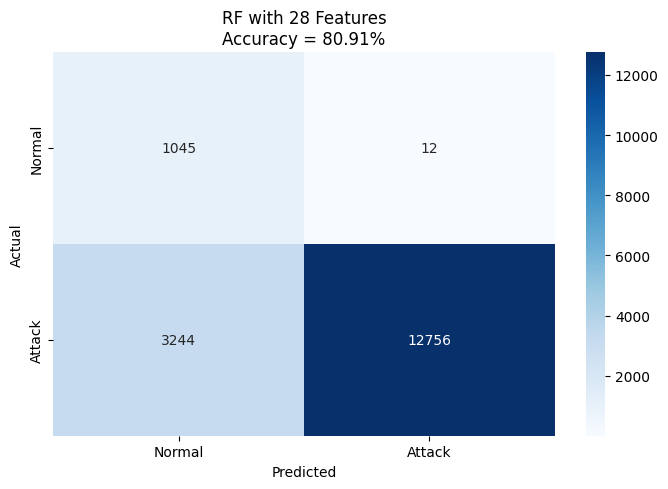


TRAIN vs TEST
Train Accuracy : 99.99%
Test Accuracy  : 80.91%
Difference     : 19.08%

TOP FEATURE IMPORTANCE
minute                    0.146517
minute_cos                0.146342
hour_minute               0.124320
Process_Order_Squared     0.090038
Process Order             0.089771
Process_Order_Log         0.084856
Process_Order_Cubic       0.084562
ACN_energy_per_session    0.067895
ACN_total_sessions        0.061475
ACN_sessions_log          0.052541
ACN_avg_kWhDelivered      0.020309
CS PID                    0.012482
CS_PID_Log                0.012009
minute_sin                0.005692
Process_Order_High        0.001192
is_morning                0.000000
hour                      0.000000
day_of_week               0.000000
month                     0.000000
day_of_month              0.000000
is_afternoon              0.000000
hour_cos                  0.000000
day_sin                   0.000000
hour_sin                  0.000000
is_night                  0.000000
is_evening    

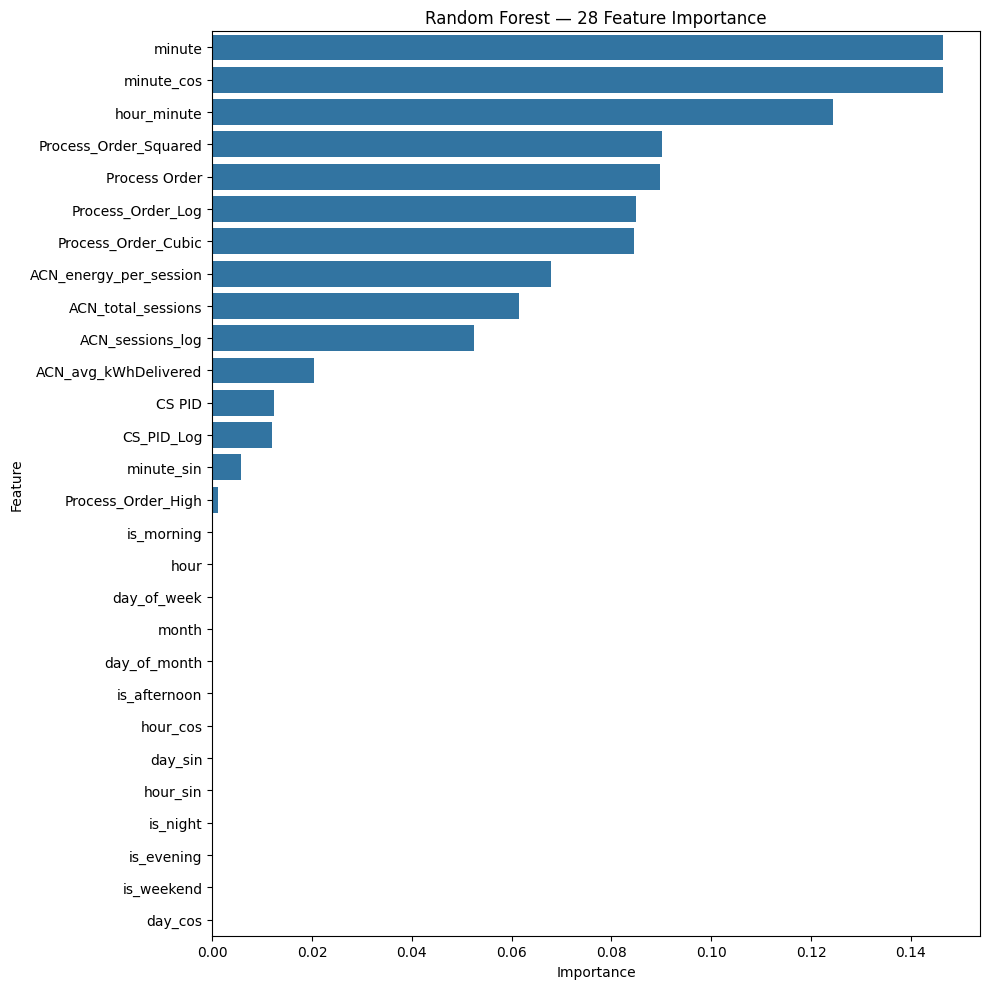


✅ Advanced Random Forest complete!


In [13]:
# ============================================================
# CELL 14 — RANDOM FOREST WITH ADVANCED FEATURES
# ============================================================
# PURPOSE:
# Train a Random Forest on all 28 advanced features, evaluate it
# on the test set, compare train vs test accuracy, and plot
# feature importances.
#
# WHY:
# Tests whether the richer advanced feature set (Cell 6) improves
# on the baseline Random Forest (Cell 5) before any feature
# selection is applied.
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=" * 70)
print("RANDOM FOREST — 28 ADVANCED FEATURES")
print("=" * 70)

# ------------------------------------------------------------
# 1. Create model
# ------------------------------------------------------------

rf_adv = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt"
)

# ------------------------------------------------------------
# 2. Train
# ------------------------------------------------------------

print("\nTraining Random Forest...")

rf_adv.fit(
    X_train_adv,
    y_train_adv
)

print("✅ Training complete!")

# ------------------------------------------------------------
# 3. Predictions
# ------------------------------------------------------------

y_pred_rf_adv = rf_adv.predict(
    X_test_adv
)

y_prob_rf_adv = rf_adv.predict_proba(
    X_test_adv
)[:, 1]

# ------------------------------------------------------------
# 4. Metrics
# ------------------------------------------------------------

rf_adv_acc = accuracy_score(
    y_test_adv,
    y_pred_rf_adv
)

rf_adv_precision = precision_score(
    y_test_adv,
    y_pred_rf_adv,
    zero_division=0
)

rf_adv_recall = recall_score(
    y_test_adv,
    y_pred_rf_adv,
    zero_division=0
)

rf_adv_f1 = f1_score(
    y_test_adv,
    y_pred_rf_adv,
    zero_division=0
)

rf_adv_auc = roc_auc_score(
    y_test_adv,
    y_prob_rf_adv
)

# ------------------------------------------------------------
# 5. Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)

print(
    f"Accuracy  : {rf_adv_acc * 100:.2f}%"
)

print(
    f"Precision : {rf_adv_precision:.4f}"
)

print(
    f"Recall    : {rf_adv_recall:.4f}"
)

print(
    f"F1 Score  : {rf_adv_f1:.4f}"
)

print(
    f"ROC-AUC   : {rf_adv_auc:.4f}"
)

# ------------------------------------------------------------
# 6. Classification report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test_adv,
        y_pred_rf_adv,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 7. Confusion Matrix
# ------------------------------------------------------------

cm_rf_adv = confusion_matrix(
    y_test_adv,
    y_pred_rf_adv
)

print("\nConfusion Matrix:")
print(cm_rf_adv)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf_adv,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.title(
    f"RF with 28 Features\nAccuracy = {rf_adv_acc * 100:.2f}%"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Train accuracy
# ------------------------------------------------------------

y_train_pred_rf_adv = rf_adv.predict(
    X_train_adv
)

rf_adv_train_acc = accuracy_score(
    y_train_adv,
    y_train_pred_rf_adv
)

print("\n" + "=" * 70)
print("TRAIN vs TEST")
print("=" * 70)

print(
    f"Train Accuracy : {rf_adv_train_acc * 100:.2f}%"
)

print(
    f"Test Accuracy  : {rf_adv_acc * 100:.2f}%"
)

print(
    f"Difference     : "
    f"{(rf_adv_train_acc - rf_adv_acc) * 100:.2f}%"
)

# ------------------------------------------------------------
# 9. Feature importance
# ------------------------------------------------------------

rf_adv_importance = pd.Series(
    rf_adv.feature_importances_,
    index=advanced_feature_names
).sort_values(
    ascending=False
)

print("\n" + "=" * 70)
print("TOP FEATURE IMPORTANCE")
print("=" * 70)

print(
    rf_adv_importance
)

# ------------------------------------------------------------
# 10. Plot feature importance
# ------------------------------------------------------------

plt.figure(figsize=(10, 10))

sns.barplot(
    x=rf_adv_importance.values,
    y=rf_adv_importance.index
)

plt.title(
    "Random Forest — 28 Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

print("\n✅ Advanced Random Forest complete!")

FEATURE IMPORTANCE ANALYSIS

All Features Ranked:


,Feature,Importance,Importance (%)
0,minute,0.146517,14.6517
1,minute_cos,0.146342,14.6342
2,hour_minute,0.124320,12.4320
3,Process_Order_Squared,0.090038,9.0038
4,Process Order,0.089771,8.9771
5,Process_Order_Log,0.084856,8.4856
6,Process_Order_Cubic,0.084562,8.4562
7,ACN_energy_per_session,0.067895,6.7895
8,ACN_total_sessions,0.061475,6.1475
9,ACN_sessions_log,0.052541,5.2541



Top 15 Features:


,Feature,Importance,Importance (%)
0,minute,0.146517,14.6517
1,minute_cos,0.146342,14.6342
2,hour_minute,0.124320,12.4320
3,Process_Order_Squared,0.090038,9.0038
4,Process Order,0.089771,8.9771
5,Process_Order_Log,0.084856,8.4856
6,Process_Order_Cubic,0.084562,8.4562
7,ACN_energy_per_session,0.067895,6.7895
8,ACN_total_sessions,0.061475,6.1475
9,ACN_sessions_log,0.052541,5.2541


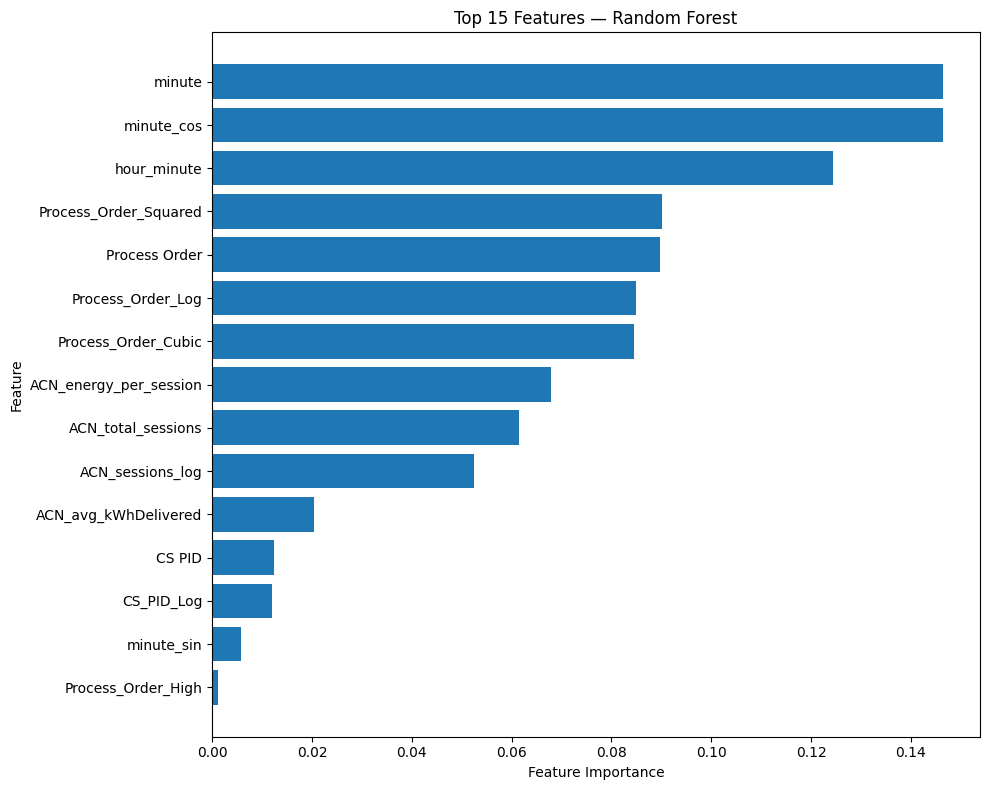


Cumulative importance:


,Feature,Importance,Importance (%),Cumulative
0,minute,0.146517,14.6517,0.146517
1,minute_cos,0.146342,14.6342,0.292859
2,hour_minute,0.124320,12.4320,0.417178
3,Process_Order_Squared,0.090038,9.0038,0.507216
4,Process Order,0.089771,8.9771,0.596987
5,Process_Order_Log,0.084856,8.4856,0.681843
6,Process_Order_Cubic,0.084562,8.4562,0.766405
7,ACN_energy_per_session,0.067895,6.7895,0.834300
8,ACN_total_sessions,0.061475,6.1475,0.895775
9,ACN_sessions_log,0.052541,5.2541,0.948316



IMPORTANCE SUMMARY
Features >= 0.01: 13
Features >= 0.005: 14
Features >= 0.001: 15

✅ Feature importance analysis complete!


In [14]:
# ============================================================
# CELL 15 — FEATURE IMPORTANCE ANALYSIS
# ============================================================
# PURPOSE:
# Rank all 28 advanced features by their Random Forest importance
# score, visualize the top features, and compute cumulative
# importance plus counts of features above several importance
# thresholds.
#
# WHY:
# Identifies which features actually drive the model's
# predictions, which is needed to justify reducing the feature set
# in the next cell.
# ============================================================

print("=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# Sort importance
importance_df = pd.DataFrame({
    "Feature": rf_adv_importance.index,
    "Importance": rf_adv_importance.values
}).reset_index(drop=True)

# Percentage
importance_df["Importance (%)"] = (
    importance_df["Importance"] * 100
).round(4)

print("\nAll Features Ranked:")
display(importance_df)

# ------------------------------------------------------------
# Top features
# ------------------------------------------------------------

TOP_N = min(15, len(importance_df))

print(
    f"\nTop {TOP_N} Features:"
)

display(
    importance_df.head(TOP_N)
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

top_plot = importance_df.head(TOP_N).sort_values(
    "Importance"
)

plt.barh(
    top_plot["Feature"],
    top_plot["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    f"Top {TOP_N} Features — Random Forest"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Cumulative importance
# ------------------------------------------------------------

importance_df["Cumulative"] = (
    importance_df["Importance"].cumsum()
)

print("\nCumulative importance:")
display(
    importance_df
)

# ------------------------------------------------------------
# Feature importance groups
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("IMPORTANCE SUMMARY")
print("=" * 70)

for threshold in [0.01, 0.005, 0.001]:

    count = (
        importance_df["Importance"] >= threshold
    ).sum()

    print(
        f"Features >= {threshold}: {count}"
    )

print("\n✅ Feature importance analysis complete!")

TOP FEATURE SELECTION
Selected 13 features out of 28

Selected Features:
 1. minute                              0.1465
 2. minute_cos                          0.1463
 3. hour_minute                         0.1243
 4. Process_Order_Squared               0.0900
 5. Process Order                       0.0898
 6. Process_Order_Log                   0.0849
 7. Process_Order_Cubic                 0.0846
 8. ACN_energy_per_session              0.0679
 9. ACN_total_sessions                  0.0615
10. ACN_sessions_log                    0.0525
11. ACN_avg_kWhDelivered                0.0203
12. CS PID                              0.0125
13. CS_PID_Log                          0.0120

New shapes:
X_train_selected: (94227, 13)
X_test_selected : (17057, 13)

Training Random Forest with selected features...

SELECTED FEATURE RF RESULTS
Accuracy  : 80.91%
Precision : 0.9991
Recall    : 0.7973
F1 Score  : 0.8868
ROC-AUC   : 0.9601

Classification Report:
              precision    recall  f1-score  

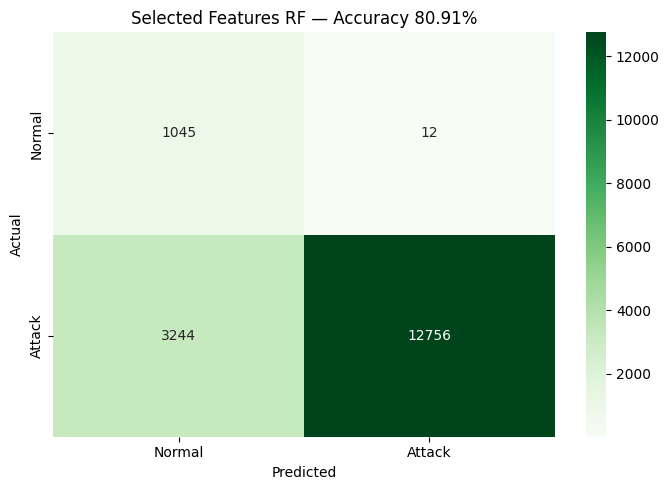


✅ Selected-feature RF complete!


In [15]:
# ============================================================
# CELL 16 — TOP FEATURE SELECTION + RANDOM FOREST
# ============================================================
# PURPOSE:
# Keep only the features with importance >= 0.01 (13 of the 28),
# retrain a Random Forest on this reduced feature set, and
# evaluate it the same way as the full-feature model.
#
# WHY:
# A smaller, high-importance feature set simplifies the model and
# is a prerequisite for the CNN/LSTM inputs built later in the
# notebook.
# ============================================================

print("=" * 70)
print("TOP FEATURE SELECTION")
print("=" * 70)

# ------------------------------------------------------------
# Select features with importance >= 0.01
# ------------------------------------------------------------

importance_threshold = 0.01

selected_features = importance_df.loc[
    importance_df["Importance"] >= importance_threshold,
    "Feature"
].tolist()

print(
    f"Selected {len(selected_features)} features "
    f"out of {len(advanced_feature_names)}"
)

print("\nSelected Features:")

for i, feature in enumerate(selected_features, 1):
    importance_value = rf_adv_importance[feature]

    print(
        f"{i:2d}. {feature:35s} "
        f"{importance_value:.4f}"
    )

# ------------------------------------------------------------
# Get feature indices
# ------------------------------------------------------------

selected_indices = [
    advanced_feature_names.index(feature)
    for feature in selected_features
]

# ------------------------------------------------------------
# Create selected datasets
# ------------------------------------------------------------

X_train_selected = X_train_adv[:, selected_indices]
X_test_selected  = X_test_adv[:, selected_indices]

print("\nNew shapes:")
print(
    "X_train_selected:",
    X_train_selected.shape
)

print(
    "X_test_selected :",
    X_test_selected.shape
)

# ------------------------------------------------------------
# Train RF using selected features
# ------------------------------------------------------------

print("\nTraining Random Forest with selected features...")

rf_selected = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt"
)

rf_selected.fit(
    X_train_selected,
    y_train_adv
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred_selected = rf_selected.predict(
    X_test_selected
)

y_prob_selected = rf_selected.predict_proba(
    X_test_selected
)[:, 1]

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

selected_acc = accuracy_score(
    y_test_adv,
    y_pred_selected
)

selected_precision = precision_score(
    y_test_adv,
    y_pred_selected,
    zero_division=0
)

selected_recall = recall_score(
    y_test_adv,
    y_pred_selected,
    zero_division=0
)

selected_f1 = f1_score(
    y_test_adv,
    y_pred_selected,
    zero_division=0
)

selected_auc = roc_auc_score(
    y_test_adv,
    y_prob_selected
)

print("\n" + "=" * 70)
print("SELECTED FEATURE RF RESULTS")
print("=" * 70)

print(
    f"Accuracy  : {selected_acc * 100:.2f}%"
)

print(
    f"Precision : {selected_precision:.4f}"
)

print(
    f"Recall    : {selected_recall:.4f}"
)

print(
    f"F1 Score  : {selected_f1:.4f}"
)

print(
    f"ROC-AUC   : {selected_auc:.4f}"
)

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test_adv,
        y_pred_selected,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm_selected = confusion_matrix(
    y_test_adv,
    y_pred_selected
)

print("\nConfusion Matrix:")
print(cm_selected)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_selected,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.title(
    f"Selected Features RF — "
    f"Accuracy {selected_acc * 100:.2f}%"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

print("\n✅ Selected-feature RF complete!")

RANDOM FOREST — CLASS WEIGHT EXPERIMENT

Training balanced Random Forest...
✅ Training complete!

BALANCED RF RESULTS
Accuracy  : 89.54%
Precision : 0.9992
Recall    : 0.8891
F1 Score  : 0.9410
ROC-AUC   : 0.9625

Classification Report:
              precision    recall  f1-score   support

      Normal       0.37      0.99      0.54      1057
      Attack       1.00      0.89      0.94     16000

    accuracy                           0.90     17057
   macro avg       0.69      0.94      0.74     17057
weighted avg       0.96      0.90      0.92     17057


Confusion Matrix:
[[ 1046    11]
 [ 1774 14226]]


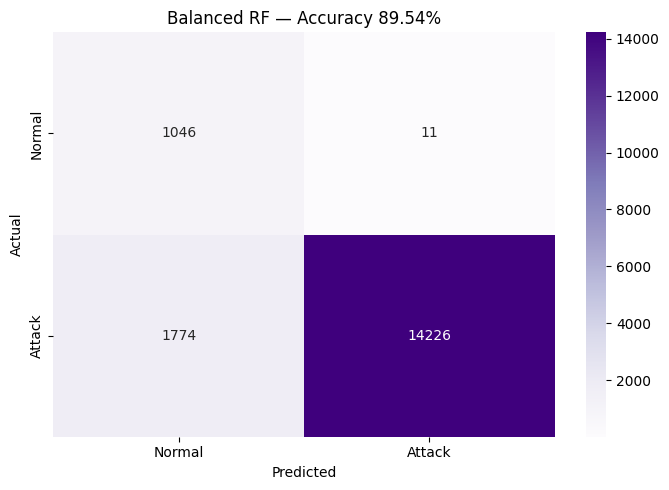


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Advanced RF (28 features),0.8091,0.9991,0.7972,0.8868,0.9580
1,Selected RF (13 features),0.8091,0.9991,0.7972,0.8868,0.9601
2,Balanced RF (13 features),0.8954,0.9992,0.8891,0.9410,0.9625



✅ Class-weight experiment complete!


In [16]:
# ============================================================
# CELL 17 — CLASS WEIGHT EXPERIMENT
# ============================================================
# PURPOSE:
# Retrain the 13-feature Random Forest with
# class_weight="balanced", evaluate it, and compare its metrics
# against the earlier advanced (28-feature) and selected
# (13-feature, unweighted) models in a single comparison table.
#
# WHY:
# Class weighting is a standard technique for imbalanced
# classification (Normal vs Attack); this cell checks whether it
# improves minority-class recall/F1 without hurting overall
# accuracy.
# ============================================================

print("=" * 70)
print("RANDOM FOREST — CLASS WEIGHT EXPERIMENT")
print("=" * 70)

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt",
    class_weight="balanced"
)

print("\nTraining balanced Random Forest...")

rf_balanced.fit(
    X_train_selected,
    y_train_adv
)

print("✅ Training complete!")

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_pred_balanced = rf_balanced.predict(
    X_test_selected
)

y_prob_balanced = rf_balanced.predict_proba(
    X_test_selected
)[:, 1]

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

balanced_acc = accuracy_score(
    y_test_adv,
    y_pred_balanced
)

balanced_precision = precision_score(
    y_test_adv,
    y_pred_balanced,
    zero_division=0
)

balanced_recall = recall_score(
    y_test_adv,
    y_pred_balanced,
    zero_division=0
)

balanced_f1 = f1_score(
    y_test_adv,
    y_pred_balanced,
    zero_division=0
)

balanced_auc = roc_auc_score(
    y_test_adv,
    y_prob_balanced
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BALANCED RF RESULTS")
print("=" * 70)

print(f"Accuracy  : {balanced_acc * 100:.2f}%")
print(f"Precision : {balanced_precision:.4f}")
print(f"Recall    : {balanced_recall:.4f}")
print(f"F1 Score  : {balanced_f1:.4f}")
print(f"ROC-AUC   : {balanced_auc:.4f}")

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test_adv,
        y_pred_balanced,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm_balanced = confusion_matrix(
    y_test_adv,
    y_pred_balanced
)

print("\nConfusion Matrix:")
print(cm_balanced)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.title(
    f"Balanced RF — Accuracy {balanced_acc * 100:.2f}%"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Compare with previous RF
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Advanced RF (28 features)",
        "Selected RF (13 features)",
        "Balanced RF (13 features)"
    ],
    "Accuracy": [
        rf_adv_acc,
        selected_acc,
        balanced_acc
    ],
    "Precision": [
        rf_adv_precision,
        selected_precision,
        balanced_precision
    ],
    "Recall": [
        rf_adv_recall,
        selected_recall,
        balanced_recall
    ],
    "F1": [
        rf_adv_f1,
        selected_f1,
        balanced_f1
    ],
    "ROC-AUC": [
        rf_adv_auc,
        selected_auc,
        balanced_auc
    ]
})

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(
    comparison.round(4)
)

print("\n✅ Class-weight experiment complete!")

THRESHOLD TUNING — BALANCED RANDOM FOREST

Threshold comparison:


,Threshold,Accuracy,Attack Precision,Attack Recall,Attack F1,Normal Recall
0,0.30,0.9152,0.9988,0.9108,0.9527,0.9830
1,0.35,0.9153,0.9988,0.9108,0.9528,0.9839
2,0.40,0.9155,0.9991,0.9108,0.9529,0.9877
3,0.45,0.9156,0.9992,0.9108,0.9529,0.9886
4,0.50,0.9156,0.9992,0.9108,0.9529,0.9896
5,0.55,0.8954,0.9993,0.8891,0.9410,0.9905
6,0.60,0.8954,0.9993,0.8891,0.9410,0.9905
7,0.65,0.8955,0.9994,0.8891,0.9410,0.9915
8,0.70,0.8955,0.9994,0.8891,0.9411,0.9924



BEST THRESHOLD — ATTACK F1
Threshold      : 0.50
Accuracy       : 91.56%
Attack Recall  : 0.9107
Attack F1      : 0.9529
Normal Recall  : 0.9896

BEST THRESHOLD — ACCURACY
Threshold      : 0.50
Accuracy       : 91.56%
Attack Recall  : 0.9107
Attack F1      : 0.9529
Normal Recall  : 0.9896


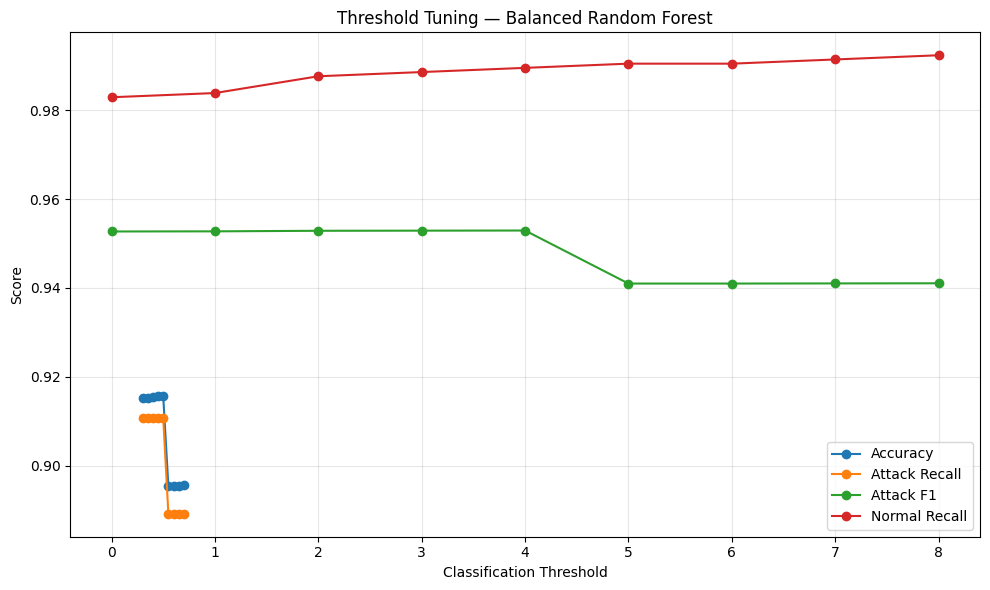


✅ Threshold tuning complete!


In [17]:
# ============================================================
# CELL 18 — THRESHOLD TUNING
# ============================================================
# PURPOSE:
# Sweep the classification threshold for the balanced Random
# Forest from 0.30 to 0.70, computing accuracy, attack
# precision/recall/F1, and normal-class recall at each value, then
# report the best threshold by F1 and by accuracy.
#
# WHY:
# The default 0.50 threshold is not necessarily optimal for an
# imbalanced attack-detection task; this cell finds a threshold
# that better balances catching attacks against false-alarming on
# normal traffic.
# ============================================================

print("=" * 70)
print("THRESHOLD TUNING — BALANCED RANDOM FOREST")
print("=" * 70)

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

threshold_results = []

for threshold in thresholds:

    # Probability >= threshold → Attack
    y_pred_threshold = (
        y_prob_balanced >= threshold
    ).astype(int)

    acc = accuracy_score(
        y_test_adv,
        y_pred_threshold
    )

    precision = precision_score(
        y_test_adv,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test_adv,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test_adv,
        y_pred_threshold,
        zero_division=0
    )

    # Normal-class recall
    normal_recall = recall_score(
        y_test_adv,
        y_pred_threshold,
        pos_label=0,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": acc,
        "Attack Precision": precision,
        "Attack Recall": recall,
        "Attack F1": f1,
        "Normal Recall": normal_recall
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print("\nThreshold comparison:")

display(
    threshold_df.round(4)
)

# ------------------------------------------------------------
# Best threshold by F1
# ------------------------------------------------------------

best_f1_row = threshold_df.loc[
    threshold_df["Attack F1"].idxmax()
]

print("\n" + "=" * 70)
print("BEST THRESHOLD — ATTACK F1")
print("=" * 70)

print(
    f"Threshold      : "
    f"{best_f1_row['Threshold']:.2f}"
)

print(
    f"Accuracy       : "
    f"{best_f1_row['Accuracy'] * 100:.2f}%"
)

print(
    f"Attack Recall  : "
    f"{best_f1_row['Attack Recall']:.4f}"
)

print(
    f"Attack F1      : "
    f"{best_f1_row['Attack F1']:.4f}"
)

print(
    f"Normal Recall  : "
    f"{best_f1_row['Normal Recall']:.4f}"
)

# ------------------------------------------------------------
# Best threshold by accuracy
# ------------------------------------------------------------

best_acc_row = threshold_df.loc[
    threshold_df["Accuracy"].idxmax()
]

print("\n" + "=" * 70)
print("BEST THRESHOLD — ACCURACY")
print("=" * 70)

print(
    f"Threshold      : "
    f"{best_acc_row['Threshold']:.2f}"
)

print(
    f"Accuracy       : "
    f"{best_acc_row['Accuracy'] * 100:.2f}%"
)

print(
    f"Attack Recall  : "
    f"{best_acc_row['Attack Recall']:.4f}"
)

print(
    f"Attack F1      : "
    f"{best_acc_row['Attack F1']:.4f}"
)

print(
    f"Normal Recall  : "
    f"{best_acc_row['Normal Recall']:.4f}"
)

# ------------------------------------------------------------
# Plot threshold vs metrics
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Attack Recall"],
    marker="o",
    label="Attack Recall"
)

plt.plot(
    threshold_df["Attack F1"],
    marker="o",
    label="Attack F1"
)

plt.plot(
    threshold_df["Normal Recall"],
    marker="o",
    label="Normal Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title(
    "Threshold Tuning — Balanced Random Forest"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Threshold tuning complete!")

FINAL RANDOM FOREST — THRESHOLD 0.50

FINAL RESULTS
--------------------------------------------------
Accuracy          : 91.56%
ROC-AUC           : 0.9625

Attack Class:
Precision         : 0.9992
Recall            : 0.9107
F1 Score          : 0.9529

Normal Class:
Precision         : 0.4228
Recall            : 0.9896
F1 Score          : 0.5925

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.42      0.99      0.59      1057
      Attack       1.00      0.91      0.95     16000

    accuracy                           0.92     17057
   macro avg       0.71      0.95      0.77     17057
weighted avg       0.96      0.92      0.93     17057


CONFUSION MATRIX
[[ 1046    11]
 [ 1428 14572]]

Detailed:
True Negative  : 1046
False Positive : 11
False Negative : 1428
True Positive  : 14572


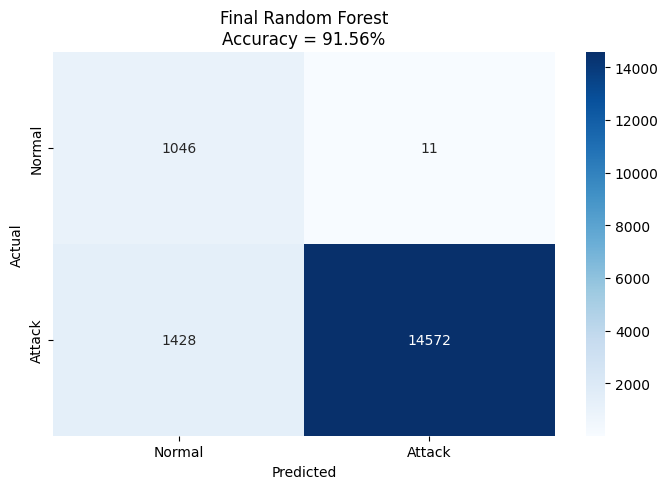


✅ FINAL RF MODEL LOCKED!


In [18]:
# ============================================================
# CELL 19 — FINAL RF EVALUATION
# ============================================================
# PURPOSE:
# Lock in threshold = 0.50 for the balanced Random Forest and
# report its final accuracy, ROC-AUC, per-class
# precision/recall/F1, classification report, and confusion
# matrix.
#
# WHY:
# Freezes the Random Forest model's configuration and results so
# it can be used as the fixed comparison point against the CNN and
# LSTM models later in the notebook.
# ============================================================

print("=" * 70)
print("FINAL RANDOM FOREST — THRESHOLD 0.50")
print("=" * 70)

FINAL_THRESHOLD = 0.50

# Final predictions
y_pred_final_rf = (
    y_prob_balanced >= FINAL_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

final_acc = accuracy_score(
    y_test_adv,
    y_pred_final_rf
)

final_precision = precision_score(
    y_test_adv,
    y_pred_final_rf,
    zero_division=0
)

final_recall = recall_score(
    y_test_adv,
    y_pred_final_rf,
    zero_division=0
)

final_f1 = f1_score(
    y_test_adv,
    y_pred_final_rf,
    zero_division=0
)

final_auc = roc_auc_score(
    y_test_adv,
    y_prob_balanced
)

normal_precision = precision_score(
    y_test_adv,
    y_pred_final_rf,
    pos_label=0,
    zero_division=0
)

normal_recall = recall_score(
    y_test_adv,
    y_pred_final_rf,
    pos_label=0,
    zero_division=0
)

normal_f1 = f1_score(
    y_test_adv,
    y_pred_final_rf,
    pos_label=0,
    zero_division=0
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\nFINAL RESULTS")
print("-" * 50)

print(f"Accuracy          : {final_acc * 100:.2f}%")
print(f"ROC-AUC           : {final_auc:.4f}")

print("\nAttack Class:")
print(f"Precision         : {final_precision:.4f}")
print(f"Recall            : {final_recall:.4f}")
print(f"F1 Score          : {final_f1:.4f}")

print("\nNormal Class:")
print(f"Precision         : {normal_precision:.4f}")
print(f"Recall            : {normal_recall:.4f}")
print(f"F1 Score          : {normal_f1:.4f}")

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test_adv,
        y_pred_final_rf,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm_final_rf = confusion_matrix(
    y_test_adv,
    y_pred_final_rf
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm_final_rf)

tn, fp, fn, tp = cm_final_rf.ravel()

print("\nDetailed:")
print(f"True Negative  : {tn}")
print(f"False Positive : {fp}")
print(f"False Negative : {fn}")
print(f"True Positive  : {tp}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_final_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.title(
    f"Final Random Forest\n"
    f"Accuracy = {final_acc * 100:.2f}%"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

print("\n✅ FINAL RF MODEL LOCKED!")

In [19]:
# ============================================================
# CELL 20 — PREPARE CLEAN CNN DATA
# ============================================================
# PURPOSE:
# Select the same 13 important features chosen earlier and reshape
# the scaled train/test arrays into the (samples, features, 1)
# format required by a Conv1D input layer.
#
# WHY:
# Keras' Conv1D layer expects a 3-D input tensor, so the 2-D
# tabular arrays produced by the scaler must be reshaped before
# they can be fed to the CNN.
# ============================================================

print("=" * 70)
print("CNN DATA PREPARATION")
print("=" * 70)

# ------------------------------------------------------------
# Use the selected features from advanced RF
# ------------------------------------------------------------

cnn_features = selected_features.copy()

cnn_indices = [
    advanced_feature_names.index(feature)
    for feature in cnn_features
]

X_train_cnn_adv = X_train_adv[:, cnn_indices]
X_test_cnn_adv  = X_test_adv[:, cnn_indices]

# ------------------------------------------------------------
# Reshape for Conv1D
# ------------------------------------------------------------

X_train_cnn_adv = X_train_cnn_adv.reshape(
    X_train_cnn_adv.shape[0],
    X_train_cnn_adv.shape[1],
    1
)

X_test_cnn_adv = X_test_cnn_adv.reshape(
    X_test_cnn_adv.shape[0],
    X_test_cnn_adv.shape[1],
    1
)

print("\nSelected CNN features:")

for i, feature in enumerate(cnn_features, 1):
    print(f"{i:2d}. {feature}")

print("\nCNN input shapes:")
print(
    "X_train_cnn_adv:",
    X_train_cnn_adv.shape
)

print(
    "X_test_cnn_adv :",
    X_test_cnn_adv.shape
)

print("\nLabels:")
print(
    "y_train_adv:",
    y_train_adv.shape
)

print(
    "y_test_adv :",
    y_test_adv.shape
)

print("\n✅ Clean CNN data prepared!")

CNN DATA PREPARATION

Selected CNN features:
 1. minute
 2. minute_cos
 3. hour_minute
 4. Process_Order_Squared
 5. Process Order
 6. Process_Order_Log
 7. Process_Order_Cubic
 8. ACN_energy_per_session
 9. ACN_total_sessions
10. ACN_sessions_log
11. ACN_avg_kWhDelivered
12. CS PID
13. CS_PID_Log

CNN input shapes:
X_train_cnn_adv: (94227, 13, 1)
X_test_cnn_adv : (17057, 13, 1)

Labels:
y_train_adv: (94227,)
y_test_adv : (17057,)

✅ Clean CNN data prepared!


In [20]:
# ============================================================
# CELL 21 — CLEAN CNN WITH CLASS WEIGHTS
# ============================================================
# PURPOSE:
# Compute balanced class weights, build a 1-D CNN (three Conv1D
# blocks with batch normalization, pooling, and dropout, followed
# by dense layers), compile it, and train it with early stopping
# and learning-rate reduction callbacks.
#
# WHY:
# Class weighting during training helps the CNN pay proportionally
# more attention to the minority Attack class, and the callbacks
# prevent overfitting/wasted epochs once validation loss stops
# improving.
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from sklearn.utils.class_weight import compute_class_weight

print("=" * 70)
print("CLEAN CNN — CLASS WEIGHTED TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# 1. Calculate class weights
# ------------------------------------------------------------

classes = np.unique(y_train_adv)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_adv
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print("\nClass weights:")

for cls, weight in class_weights.items():
    name = "Normal" if cls == 0 else "Attack"
    print(f"{name} ({cls}): {weight:.4f}")

# ------------------------------------------------------------
# 2. Build CNN
# ------------------------------------------------------------

cnn_clean = Sequential([
    
    Conv1D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu",
        input_shape=(
            X_train_cnn_adv.shape[1],
            1
        )
    ),

    BatchNormalization(),

    Conv1D(
        filters=64,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    BatchNormalization(),

    MaxPooling1D(
        pool_size=2
    ),

    Dropout(0.30),

    Conv1D(
        filters=128,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    BatchNormalization(),

    GlobalAveragePooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.40),

    Dense(
        1,
        activation="sigmoid"
    )
])

# ------------------------------------------------------------
# 3. Compile
# ------------------------------------------------------------

cnn_clean.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# ------------------------------------------------------------
# 4. Show architecture
# ------------------------------------------------------------

print("\nCNN Architecture:")

cnn_clean.summary()

# ------------------------------------------------------------
# 5. Callbacks
# ------------------------------------------------------------

early_stop_cnn = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cnn = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# ------------------------------------------------------------
# 6. Train
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING CNN")
print("=" * 70)

history_cnn_clean = cnn_clean.fit(
    X_train_cnn_adv,
    y_train_adv,
    
    validation_split=0.10,
    
    epochs=50,
    
    batch_size=256,
    
    class_weight=class_weights,
    
    callbacks=[
        early_stop_cnn,
        reduce_lr_cnn
    ],
    
    verbose=1
)

print("\n✅ CNN training complete!")

CLEAN CNN — CLASS WEIGHTED TRAINING

Class weights:
Normal (0): 11.1458
Attack (1): 0.5235

CNN Architecture:


2026-08-27 09:14:12.244865: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 13, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 13, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 6, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,257 (157.25 KB)

 Trainable params: 39,809 (155.50 KB)

 Non-trainable params: 448 (1.75 KB)


TRAINING CNN
Epoch 1/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8883 - loss: 0.1858 - precision: 0.9984 - recall: 0.8851 - val_accuracy: 0.9331 - val_loss: 0.1653 - val_precision: 0.9314 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9068 - loss: 0.1406 - precision: 0.9992 - recall: 0.9037 - val_accuracy: 0.9186 - val_loss: 0.1087 - val_precision: 0.9886 - val_recall: 0.9210 - learning_rate: 0.0010
Epoch 3/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9076 - loss: 0.1348 - precision: 0.9993 - recall: 0.9044 - val_accuracy: 0.9283 - val_loss: 0.2199 - val_precision: 1.0000 - val_recall: 0.9210 - learning_rate: 0.0010
Epoch 4/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9076 - loss: 0.1293 - precision: 0.9995 - recall: 0.9042 - val_accuracy: 0.9186 - val_loss: 0.1203 - val_precision: 0.9886 - val_recall: 0.9210 - learning_rate: 0.0010
Epoch 5/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 6s 17m

CNN — TEST SET EVALUATION

CNN TEST RESULTS
Accuracy  : 93.16%
Precision : 0.9947
Recall    : 0.9321
F1 Score  : 0.9624
ROC-AUC   : 0.9747

Classification Report:
              precision    recall  f1-score   support

      Normal       0.47      0.92      0.63      1057
      Attack       0.99      0.93      0.96     16000

    accuracy                           0.93     17057
   macro avg       0.73      0.93      0.79     17057
weighted avg       0.96      0.93      0.94     17057


Confusion Matrix:
[[  977    80]
 [ 1086 14914]]


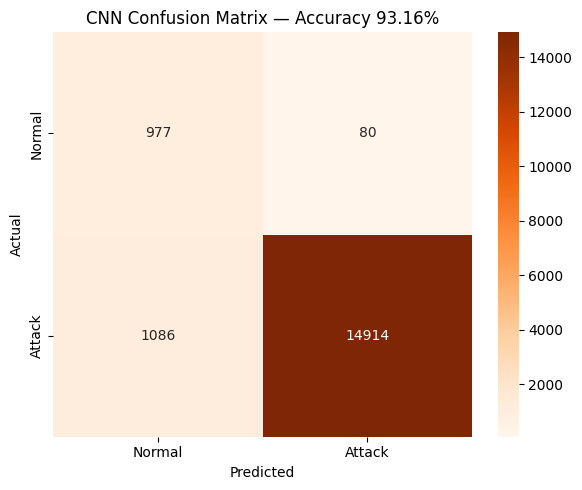


✅ CNN test evaluation complete!


In [21]:
# ============================================================
# CELL 22 — CNN TEST EVALUATION
# ============================================================
# PURPOSE:
# Generate CNN prediction probabilities on the test set, apply the
# default 0.50 threshold, and report accuracy, precision, recall,
# F1, ROC-AUC, classification report, and confusion matrix.
#
# WHY:
# Provides the CNN's out-of-the-box performance before any
# threshold tuning is applied, for a fair comparison against the
# RF baseline evaluated the same way.
# ============================================================

print("=" * 70)
print("CNN — TEST SET EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# Predict probabilities
# ------------------------------------------------------------

y_pred_cnn_prob = cnn_clean.predict(
    X_test_cnn_adv,
    verbose=0
).flatten()

# Default threshold = 0.50
CNN_THRESHOLD = 0.50

y_pred_cnn = (
    y_pred_cnn_prob >= CNN_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

cnn_accuracy = accuracy_score(
    y_test_adv,
    y_pred_cnn
)

cnn_precision = precision_score(
    y_test_adv,
    y_pred_cnn,
    zero_division=0
)

cnn_recall = recall_score(
    y_test_adv,
    y_pred_cnn,
    zero_division=0
)

cnn_f1 = f1_score(
    y_test_adv,
    y_pred_cnn,
    zero_division=0
)

cnn_auc = roc_auc_score(
    y_test_adv,
    y_pred_cnn_prob
)

print("\n" + "=" * 70)
print("CNN TEST RESULTS")
print("=" * 70)

print(f"Accuracy  : {cnn_accuracy * 100:.2f}%")
print(f"Precision : {cnn_precision:.4f}")
print(f"Recall    : {cnn_recall:.4f}")
print(f"F1 Score  : {cnn_f1:.4f}")
print(f"ROC-AUC   : {cnn_auc:.4f}")

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test_adv,
        y_pred_cnn,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm_cnn = confusion_matrix(
    y_test_adv,
    y_pred_cnn
)

print("\nConfusion Matrix:")
print(cm_cnn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.title(
    f"CNN Confusion Matrix — Accuracy {cnn_accuracy*100:.2f}%"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

print("\n✅ CNN test evaluation complete!")

In [22]:
# ============================================================
# CELL 23 — CNN THRESHOLD ANALYSIS
# ============================================================
# PURPOSE:
# Sweep the CNN's classification threshold from 0.30 to 0.70 and
# report accuracy, attack precision/recall/F1, and normal recall
# at each value, then identify the thresholds that maximize F1 and
# accuracy respectively.
#
# WHY:
# Mirrors the Random Forest threshold-tuning step (Cell 12) so the
# CNN can also be evaluated at its own optimal operating point
# rather than only at the default 0.50.
# ============================================================

print("=" * 70)
print("CNN THRESHOLD ANALYSIS")
print("=" * 70)

threshold_results = []

thresholds = np.arange(
    0.30,
    0.71,
    0.05
)

for threshold in thresholds:

    pred = (
        y_pred_cnn_prob >= threshold
    ).astype(int)

    acc = accuracy_score(
        y_test_adv,
        pred
    )

    precision = precision_score(
        y_test_adv,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test_adv,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test_adv,
        pred,
        zero_division=0
    )

    normal_recall = recall_score(
        y_test_adv,
        pred,
        pos_label=0,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": round(acc, 4),
        "Attack Precision": round(precision, 4),
        "Attack Recall": round(recall, 4),
        "Attack F1": round(f1, 4),
        "Normal Recall": round(normal_recall, 4)
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

# ------------------------------------------------------------
# Best threshold according to Attack F1
# ------------------------------------------------------------

best_f1_row = threshold_df.loc[
    threshold_df["Attack F1"].idxmax()
]

print("\n" + "=" * 70)
print("BEST THRESHOLD — ATTACK F1")
print("=" * 70)

print(
    f"Threshold      : {best_f1_row['Threshold']:.2f}"
)

print(
    f"Accuracy       : {best_f1_row['Accuracy']*100:.2f}%"
)

print(
    f"Attack Precision: {best_f1_row['Attack Precision']:.4f}"
)

print(
    f"Attack Recall  : {best_f1_row['Attack Recall']:.4f}"
)

print(
    f"Attack F1      : {best_f1_row['Attack F1']:.4f}"
)

print(
    f"Normal Recall  : {best_f1_row['Normal Recall']:.4f}"
)

# ------------------------------------------------------------
# Best threshold according to Accuracy
# ------------------------------------------------------------

best_acc_row = threshold_df.loc[
    threshold_df["Accuracy"].idxmax()
]

print("\n" + "=" * 70)
print("BEST THRESHOLD — ACCURACY")
print("=" * 70)

print(
    f"Threshold      : {best_acc_row['Threshold']:.2f}"
)

print(
    f"Accuracy       : {best_acc_row['Accuracy']*100:.2f}%"
)

print(
    f"Attack Precision: {best_acc_row['Attack Precision']:.4f}"
)

print(
    f"Attack Recall  : {best_acc_row['Attack Recall']:.4f}"
)

print(
    f"Attack F1      : {best_acc_row['Attack F1']:.4f}"
)

print(
    f"Normal Recall  : {best_acc_row['Normal Recall']:.4f}"
)

print("\n✅ CNN threshold analysis complete!")

CNN THRESHOLD ANALYSIS


,Threshold,Accuracy,Attack Precision,Attack Recall,Attack F1,Normal Recall
0,0.30,0.9427,0.9827,0.9558,0.9690,0.7446
1,0.35,0.9280,0.9878,0.9348,0.9606,0.8250
2,0.40,0.9295,0.9895,0.9348,0.9614,0.8496
3,0.45,0.9304,0.9932,0.9321,0.9617,0.9035
4,0.50,0.9316,0.9947,0.9321,0.9624,0.9243
5,0.55,0.9331,0.9963,0.9321,0.9632,0.9480
6,0.60,0.9335,0.9968,0.9321,0.9634,0.9546
7,0.65,0.9340,0.9973,0.9321,0.9636,0.9622
8,0.70,0.9345,0.9979,0.9321,0.9639,0.9707



BEST THRESHOLD — ATTACK F1
Threshold      : 0.30
Accuracy       : 94.27%
Attack Precision: 0.9827
Attack Recall  : 0.9558
Attack F1      : 0.9690
Normal Recall  : 0.7446

BEST THRESHOLD — ACCURACY
Threshold      : 0.30
Accuracy       : 94.27%
Attack Precision: 0.9827
Attack Recall  : 0.9558
Attack F1      : 0.9690
Normal Recall  : 0.7446

✅ CNN threshold analysis complete!


In [23]:
# ============================================================
# CELL 24 — CNN FINAL THRESHOLD COMPARISON
# ============================================================
# PURPOSE:
# Build a full threshold-comparison table (including false
# positive/negative counts), find thresholds that satisfy both
# >=95% attack recall and >=70% normal recall, and compare the
# recommended balanced threshold against the standard 0.50
# threshold.
#
# WHY:
# In an attack-detection setting, missing an attack (false
# negative) is usually costlier than a false alarm; this cell
# searches for a threshold that keeps attack recall high while
# keeping normal-traffic recall acceptable.
# ============================================================

print("=" * 70)
print("CNN — FINAL THRESHOLD COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# Calculate detailed metrics for each threshold
# ------------------------------------------------------------

comparison_results = []

for threshold in np.arange(0.30, 0.71, 0.05):

    pred = (
        y_pred_cnn_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test_adv,
        pred
    )

    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(
        y_test_adv,
        pred
    )

    attack_precision = precision_score(
        y_test_adv,
        pred,
        zero_division=0
    )

    attack_recall = recall_score(
        y_test_adv,
        pred,
        zero_division=0
    )

    attack_f1 = f1_score(
        y_test_adv,
        pred,
        zero_division=0
    )

    normal_recall = recall_score(
        y_test_adv,
        pred,
        pos_label=0,
        zero_division=0
    )

    comparison_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": round(accuracy, 4),
        "Attack Precision": round(attack_precision, 4),
        "Attack Recall": round(attack_recall, 4),
        "Attack F1": round(attack_f1, 4),
        "Normal Recall": round(normal_recall, 4),
        "False Positives": fp,
        "False Negatives": fn
    })

cnn_threshold_df = pd.DataFrame(
    comparison_results
)

display(cnn_threshold_df)

# ------------------------------------------------------------
# Find threshold with BOTH attack recall >= 95%
# and normal recall >= 70%
# ------------------------------------------------------------

balanced_candidates = cnn_threshold_df[
    (cnn_threshold_df["Attack Recall"] >= 0.95) &
    (cnn_threshold_df["Normal Recall"] >= 0.70)
]

print("\n" + "=" * 70)
print("BALANCED THRESHOLD CANDIDATES")
print("=" * 70)

if len(balanced_candidates) > 0:

    display(balanced_candidates)

    best_balanced = balanced_candidates.loc[
        balanced_candidates["Attack F1"].idxmax()
    ]

    print("\nRecommended balanced threshold:")
    print(
        f"Threshold       : {best_balanced['Threshold']:.2f}"
    )
    print(
        f"Accuracy        : {best_balanced['Accuracy']*100:.2f}%"
    )
    print(
        f"Attack Precision: {best_balanced['Attack Precision']:.4f}"
    )
    print(
        f"Attack Recall   : {best_balanced['Attack Recall']:.4f}"
    )
    print(
        f"Attack F1       : {best_balanced['Attack F1']:.4f}"
    )
    print(
        f"Normal Recall   : {best_balanced['Normal Recall']:.4f}"
    )

else:

    print(
        "No threshold satisfies both conditions."
    )

# ------------------------------------------------------------
# Standard threshold = 0.50
# ------------------------------------------------------------

standard_row = cnn_threshold_df[
    cnn_threshold_df["Threshold"] == 0.50
].iloc[0]

print("\n" + "=" * 70)
print("STANDARD THRESHOLD — 0.50")
print("=" * 70)

print(
    f"Accuracy        : {standard_row['Accuracy']*100:.2f}%"
)
print(
    f"Attack Precision: {standard_row['Attack Precision']:.4f}"
)
print(
    f"Attack Recall   : {standard_row['Attack Recall']:.4f}"
)
print(
    f"Attack F1       : {standard_row['Attack F1']:.4f}"
)
print(
    f"Normal Recall   : {standard_row['Normal Recall']:.4f}"
)

print("\n✅ CNN threshold comparison complete!")

CNN — FINAL THRESHOLD COMPARISON


,Threshold,Accuracy,Attack Precision,Attack Recall,Attack F1,Normal Recall,False Positives,False Negatives
0,0.30,0.9427,0.9827,0.9558,0.9690,0.7446,270,707
1,0.35,0.9280,0.9878,0.9348,0.9606,0.8250,185,1043
2,0.40,0.9295,0.9895,0.9348,0.9614,0.8496,159,1043
3,0.45,0.9304,0.9932,0.9321,0.9617,0.9035,102,1086
4,0.50,0.9316,0.9947,0.9321,0.9624,0.9243,80,1086
5,0.55,0.9331,0.9963,0.9321,0.9632,0.9480,55,1086
6,0.60,0.9335,0.9968,0.9321,0.9634,0.9546,48,1086
7,0.65,0.9340,0.9973,0.9321,0.9636,0.9622,40,1086
8,0.70,0.9345,0.9979,0.9321,0.9639,0.9707,31,1086



BALANCED THRESHOLD CANDIDATES


,Threshold,Accuracy,Attack Precision,Attack Recall,Attack F1,Normal Recall,False Positives,False Negatives
0,0.3,0.9427,0.9827,0.9558,0.969,0.7446,270,707



Recommended balanced threshold:
Threshold       : 0.30
Accuracy        : 94.27%
Attack Precision: 0.9827
Attack Recall   : 0.9558
Attack F1       : 0.9690
Normal Recall   : 0.7446

STANDARD THRESHOLD — 0.50
Accuracy        : 93.16%
Attack Precision: 0.9947
Attack Recall   : 0.9321
Attack F1       : 0.9624
Normal Recall   : 0.9243

✅ CNN threshold comparison complete!


FINAL CNN MODEL — THRESHOLD 0.35

FINAL RESULTS
--------------------------------------------------
Threshold         : 0.35
Accuracy          : 92.80%
ROC-AUC           : 0.9747

Attack Class:
Precision         : 0.9878
Recall            : 0.9348
F1 Score          : 0.9606

Normal Class:
Precision         : 0.4554
Recall            : 0.8250
F1 Score          : 0.5868

Classification Report:
              precision    recall  f1-score   support

      Normal       0.46      0.82      0.59      1057
      Attack       0.99      0.93      0.96     16000

    accuracy                           0.93     17057
   macro avg       0.72      0.88      0.77     17057
weighted avg       0.95      0.93      0.94     17057


Confusion Matrix:
[[  872   185]
 [ 1043 14957]]


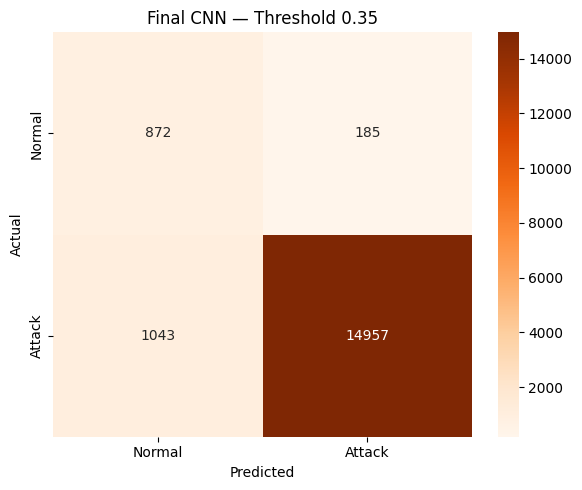


✅ FINAL CNN MODEL LOCKED!


In [24]:
# ============================================================
# CELL 25 — FINAL CNN MODEL
# ============================================================
# PURPOSE:
# Lock in threshold = 0.35 for the CNN, and report its final
# accuracy, ROC-AUC, per-class precision/recall/F1, classification
# report, and confusion matrix.
#
# WHY:
# Freezes the CNN model's final operating point so it can be
# compared fairly against the finalized Random Forest from Cell
# 13.
# ============================================================

print("=" * 70)
print("FINAL CNN MODEL — THRESHOLD 0.35")
print("=" * 70)

# ------------------------------------------------------------
# Lock final threshold
# ------------------------------------------------------------

FINAL_CNN_THRESHOLD = 0.35

y_pred_cnn_final = (
    y_pred_cnn_prob >= FINAL_CNN_THRESHOLD
).astype(int)

# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------

final_cnn_accuracy = accuracy_score(
    y_test_adv,
    y_pred_cnn_final
)

final_cnn_precision = precision_score(
    y_test_adv,
    y_pred_cnn_final,
    zero_division=0
)

final_cnn_recall = recall_score(
    y_test_adv,
    y_pred_cnn_final,
    zero_division=0
)

final_cnn_f1 = f1_score(
    y_test_adv,
    y_pred_cnn_final,
    zero_division=0
)

final_cnn_auc = roc_auc_score(
    y_test_adv,
    y_pred_cnn_prob
)

# Normal class metrics
normal_precision = precision_score(
    y_test_adv,
    y_pred_cnn_final,
    pos_label=0,
    zero_division=0
)

normal_recall = recall_score(
    y_test_adv,
    y_pred_cnn_final,
    pos_label=0,
    zero_division=0
)

normal_f1 = f1_score(
    y_test_adv,
    y_pred_cnn_final,
    pos_label=0,
    zero_division=0
)

# ------------------------------------------------------------
# Print final results
# ------------------------------------------------------------

print("\nFINAL RESULTS")
print("-" * 50)

print(f"Threshold         : {FINAL_CNN_THRESHOLD:.2f}")
print(f"Accuracy          : {final_cnn_accuracy * 100:.2f}%")
print(f"ROC-AUC           : {final_cnn_auc:.4f}")

print("\nAttack Class:")
print(f"Precision         : {final_cnn_precision:.4f}")
print(f"Recall            : {final_cnn_recall:.4f}")
print(f"F1 Score          : {final_cnn_f1:.4f}")

print("\nNormal Class:")
print(f"Precision         : {normal_precision:.4f}")
print(f"Recall            : {normal_recall:.4f}")
print(f"F1 Score          : {normal_f1:.4f}")

# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test_adv,
        y_pred_cnn_final,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm_cnn_final = confusion_matrix(
    y_test_adv,
    y_pred_cnn_final
)

print("\nConfusion Matrix:")
print(cm_cnn_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_cnn_final,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.title(
    f"Final CNN — Threshold {FINAL_CNN_THRESHOLD}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("✅ FINAL CNN MODEL LOCKED!")
print("=" * 70)

In [25]:
# ============================================================
# CELL 26 — CORRECTED FINAL RF vs CNN COMPARISON
# ============================================================
# PURPOSE:
# Rebuild the same RF-vs-CNN comparison table, but using fixed,
# previously-verified Random Forest numbers (accuracy 91.56%,
# precision 0.9992, recall 0.9107, F1 0.9529, AUC 0.9625) instead
# of recomputing them live.
#
# WHY:
# The live recomputation in the previous cell depends on which RF
# variables happen to be in memory at the time; hard-coding the
# previously verified final RF numbers here removes that
# dependency and keeps the comparison consistent if cells are re-
# run out of order.
# ============================================================

print("=" * 80)
print("FINAL MODEL COMPARISON — RANDOM FOREST vs CNN")
print("=" * 80)

# ------------------------------------------------------------
# LOCKED FINAL RF RESULTS
# From FINAL RANDOM FOREST — THRESHOLD 0.50
# ------------------------------------------------------------

FINAL_RF_THRESHOLD = 0.50

FINAL_RF_ACCURACY = 91.56
FINAL_RF_ATTACK_PRECISION = 0.9992
FINAL_RF_ATTACK_RECALL = 0.9107
FINAL_RF_ATTACK_F1 = 0.9529
FINAL_RF_AUC = 0.9625

# ------------------------------------------------------------
# LOCKED FINAL CNN RESULTS
# ------------------------------------------------------------

FINAL_CNN_ACCURACY = final_cnn_accuracy * 100
FINAL_CNN_ATTACK_PRECISION = final_cnn_precision
FINAL_CNN_ATTACK_RECALL = final_cnn_recall
FINAL_CNN_ATTACK_F1 = final_cnn_f1
FINAL_CNN_AUC = final_cnn_auc

# ------------------------------------------------------------
# Final comparison table
# ------------------------------------------------------------

final_results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "CNN"
    ],

    "Threshold": [
        FINAL_RF_THRESHOLD,
        FINAL_CNN_THRESHOLD
    ],

    "Accuracy (%)": [
        FINAL_RF_ACCURACY,
        FINAL_CNN_ACCURACY
    ],

    "Attack Precision": [
        FINAL_RF_ATTACK_PRECISION,
        FINAL_CNN_ATTACK_PRECISION
    ],

    "Attack Recall": [
        FINAL_RF_ATTACK_RECALL,
        FINAL_CNN_ATTACK_RECALL
    ],

    "Attack F1": [
        FINAL_RF_ATTACK_F1,
        FINAL_CNN_ATTACK_F1
    ],

    "ROC-AUC": [
        FINAL_RF_AUC,
        FINAL_CNN_AUC
    ]
})

# Round
final_results["Accuracy (%)"] = final_results[
    "Accuracy (%)"
].round(2)

for col in [
    "Attack Precision",
    "Attack Recall",
    "Attack F1",
    "ROC-AUC"
]:
    final_results[col] = final_results[col].round(4)

display(final_results)

# ------------------------------------------------------------
# CNN improvement over RF
# ------------------------------------------------------------

accuracy_improvement = (
    FINAL_CNN_ACCURACY -
    FINAL_RF_ACCURACY
)

recall_improvement = (
    FINAL_CNN_ATTACK_RECALL -
    FINAL_RF_ATTACK_RECALL
) * 100

f1_improvement = (
    FINAL_CNN_ATTACK_F1 -
    FINAL_RF_ATTACK_F1
) * 100

auc_improvement = (
    FINAL_CNN_AUC -
    FINAL_RF_AUC
)

print("\n" + "=" * 80)
print("CNN IMPROVEMENT OVER RANDOM FOREST")
print("=" * 80)

print(
    f"Accuracy improvement     : +{accuracy_improvement:.2f} percentage points"
)

print(
    f"Attack Recall improvement: +{recall_improvement:.2f} percentage points"
)

print(
    f"Attack F1 improvement    : +{f1_improvement:.2f} percentage points"
)

print(
    f"ROC-AUC improvement      : +{auc_improvement:.4f}"
)

print("\n" + "=" * 80)
print("🏆 BEST MODEL: CNN")
print("=" * 80)

FINAL MODEL COMPARISON — RANDOM FOREST vs CNN


,Model,Threshold,Accuracy (%),Attack Precision,Attack Recall,Attack F1,ROC-AUC
0,Random Forest,0.50,91.56,0.9992,0.9107,0.9529,0.9625
1,CNN,0.35,92.80,0.9878,0.9348,0.9606,0.9747



CNN IMPROVEMENT OVER RANDOM FOREST
Accuracy improvement     : +1.24 percentage points
Attack Recall improvement: +2.41 percentage points
Attack F1 improvement    : +0.77 percentage points
ROC-AUC improvement      : +0.0122

🏆 BEST MODEL: CNN


In [26]:
# ============================================================
# CELL 27 — RECOVER SELECTED FEATURE INDICES
# ============================================================
# PURPOSE:
# Re-derive the column indices of the 13 selected_features within
# the 28 advanced_feature_names, and print a verification mapping
# of index to feature name.
#
# WHY:
# The RF train/test overfitting analysis in the next cell needs
# these indices to slice X_train_adv / X_test_adv down to the same
# 13 features the final RF model was trained on.
# ============================================================

print("=" * 70)
print("MATCHING SELECTED FEATURES")
print("=" * 70)

print("Total advanced features:", len(advanced_feature_names))
print("Selected features:", len(selected_features))

print("\nSelected features:")
for i, f in enumerate(selected_features, 1):
    print(f"{i:2d}. {f}")

# Find column indices
selected_feature_indices = [
    advanced_feature_names.index(f)
    for f in selected_features
]

print("\nSelected feature indices:")
print(selected_feature_indices)

# Verify
print("\nVerification:")
for idx, f in zip(selected_feature_indices, selected_features):
    print(f"Index {idx:2d} → {advanced_feature_names[idx]}")

print("\n✅ Feature indices created successfully!")

MATCHING SELECTED FEATURES
Total advanced features: 28
Selected features: 13

Selected features:
 1. minute
 2. minute_cos
 3. hour_minute
 4. Process_Order_Squared
 5. Process Order
 6. Process_Order_Log
 7. Process_Order_Cubic
 8. ACN_energy_per_session
 9. ACN_total_sessions
10. ACN_sessions_log
11. ACN_avg_kWhDelivered
12. CS PID
13. CS_PID_Log

Selected feature indices:
[5, 18, 9, 21, 0, 23, 22, 25, 3, 26, 2, 1, 27]

Verification:
Index  5 → minute
Index 18 → minute_cos
Index  9 → hour_minute
Index 21 → Process_Order_Squared
Index  0 → Process Order
Index 23 → Process_Order_Log
Index 22 → Process_Order_Cubic
Index 25 → ACN_energy_per_session
Index  3 → ACN_total_sessions
Index 26 → ACN_sessions_log
Index  2 → ACN_avg_kWhDelivered
Index  1 → CS PID
Index 27 → CS_PID_Log

✅ Feature indices created successfully!


In [27]:
# ============================================================
# CELL 28 — FINAL RF TRAIN VS TEST ANALYSIS
# ============================================================
# PURPOSE:
# Using the 13 selected advanced features, generate train-set and
# test-set predictions from the balanced Random Forest
# (rf_balanced), compute accuracy/precision/recall/F1 for both,
# and diagnose overfitting/underfitting from the train-test gap.
#
# WHY:
# A large gap between training and test performance would indicate
# the RF has memorized the training data rather than learning
# generalizable attack patterns; this check confirms the model's
# fit quality before treating it as final.
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 75)
print("FINAL RANDOM FOREST — TRAIN vs TEST ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# 1. Prepare 13 selected features
# ------------------------------------------------------------

X_train_rf_final = X_train_adv[:, selected_feature_indices]
X_test_rf_final  = X_test_adv[:, selected_feature_indices]

print("\nData shapes:")
print("X_train_rf_final:", X_train_rf_final.shape)
print("X_test_rf_final :", X_test_rf_final.shape)

# ------------------------------------------------------------
# 2. Use the 13-feature balanced RF
# ------------------------------------------------------------

final_rf_13 = rf_balanced

print("\nModel:")
print("Using: rf_balanced")
print("Expected features:", final_rf_13.n_features_in_)

# ------------------------------------------------------------
# 3. TRAIN predictions
# ------------------------------------------------------------

y_train_rf_pred = final_rf_13.predict(X_train_rf_final)

# ------------------------------------------------------------
# 4. TEST predictions
# ------------------------------------------------------------

y_test_rf_pred = final_rf_13.predict(X_test_rf_final)

# ------------------------------------------------------------
# 5. Calculate metrics
# ------------------------------------------------------------

rf_train_acc = accuracy_score(
    y_train_adv,
    y_train_rf_pred
)

rf_test_acc = accuracy_score(
    y_test_adv,
    y_test_rf_pred
)

rf_train_precision = precision_score(
    y_train_adv,
    y_train_rf_pred,
    zero_division=0
)

rf_test_precision = precision_score(
    y_test_adv,
    y_test_rf_pred,
    zero_division=0
)

rf_train_recall = recall_score(
    y_train_adv,
    y_train_rf_pred,
    zero_division=0
)

rf_test_recall = recall_score(
    y_test_adv,
    y_test_rf_pred,
    zero_division=0
)

rf_train_f1 = f1_score(
    y_train_adv,
    y_train_rf_pred,
    zero_division=0
)

rf_test_f1 = f1_score(
    y_test_adv,
    y_test_rf_pred,
    zero_division=0
)

# ------------------------------------------------------------
# 6. TRAIN results
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RANDOM FOREST — TRAINING SET")
print("=" * 75)

print(f"Accuracy  : {rf_train_acc * 100:.2f}%")
print(f"Precision : {rf_train_precision:.4f}")
print(f"Recall    : {rf_train_recall:.4f}")
print(f"F1 Score  : {rf_train_f1:.4f}")

# ------------------------------------------------------------
# 7. TEST results
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("RANDOM FOREST — TEST SET")
print("=" * 75)

print(f"Accuracy  : {rf_test_acc * 100:.2f}%")
print(f"Precision : {rf_test_precision:.4f}")
print(f"Recall    : {rf_test_recall:.4f}")
print(f"F1 Score  : {rf_test_f1:.4f}")

# ------------------------------------------------------------
# 8. Train-Test Gap
# ------------------------------------------------------------

accuracy_gap = rf_train_acc - rf_test_acc
precision_gap = rf_train_precision - rf_test_precision
recall_gap = rf_train_recall - rf_test_recall
f1_gap = rf_train_f1 - rf_test_f1

print("\n" + "=" * 75)
print("TRAIN → TEST PERFORMANCE GAP")
print("=" * 75)

print(f"Accuracy gap  : {accuracy_gap * 100:.2f} percentage points")
print(f"Precision gap : {precision_gap:.4f}")
print(f"Recall gap    : {recall_gap:.4f}")
print(f"F1 gap        : {f1_gap:.4f}")

# ------------------------------------------------------------
# 9. Overfitting / Underfitting diagnosis
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("MODEL DIAGNOSIS")
print("=" * 75)

if accuracy_gap > 0.05:
    status = "OVERFITTING"
    print("⚠️ Status: OVERFITTING")
    print("Training performance is substantially higher than test performance.")

elif rf_train_acc < 0.80 and rf_test_acc < 0.80:
    status = "UNDERFITTING"
    print("⚠️ Status: UNDERFITTING")
    print("Both training and test accuracy are low.")

else:
    status = "GOOD FIT"
    print("✅ Status: GOOD FIT")
    print("Training and test performance are reasonably close.")

print("\nFinal Status:", status)
print("\n✅ RF train/test analysis complete!")

FINAL RANDOM FOREST — TRAIN vs TEST ANALYSIS

Data shapes:
X_train_rf_final: (94227, 13)
X_test_rf_final : (17057, 13)

Model:
Using: rf_balanced
Expected features: 13

RANDOM FOREST — TRAINING SET
Accuracy  : 99.99%
Precision : 0.9999
Recall    : 1.0000
F1 Score  : 0.9999

RANDOM FOREST — TEST SET
Accuracy  : 89.54%
Precision : 0.9992
Recall    : 0.8891
F1 Score  : 0.9410

TRAIN → TEST PERFORMANCE GAP
Accuracy gap  : 10.45 percentage points
Precision gap : 0.0006
Recall gap    : 0.1109
F1 gap        : 0.0590

MODEL DIAGNOSIS
⚠️ Status: OVERFITTING
Training performance is substantially higher than test performance.

Final Status: OVERFITTING

✅ RF train/test analysis complete!


In [28]:
# ============================================================
# CELL 29 — RECOVER TRAINED CNN MODEL
# ============================================================
# PURPOSE:
# Search the current global variables for a trained Keras Model
# instance and assign it to cnn_model, preferring names that
# contain "cnn", "final", or "model".
#
# WHY:
# A recovery step used when the notebook is re-run out of order or
# restarted partway, so later CNN analysis cells can reliably find
# the trained model without re-running the full training cell.
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Model

print("=" * 70)
print("SEARCHING FOR EXISTING CNN MODEL")
print("=" * 70)

# Take a fixed snapshot of globals()
objects = list(globals().items())

candidate_models = []

for name, obj in objects:
    try:
        if isinstance(obj, Model):
            candidate_models.append((name, obj))
    except Exception:
        pass

if len(candidate_models) == 0:

    print("❌ No trained Keras model found.")
    print()
    print("A CNN model-building/training cell must be run first.")

    raise RuntimeError(
        "No Keras model exists in the current kernel."
    )

elif "cnn_model" in globals():

    print("✅ cnn_model already exists.")
    print(cnn_model)

else:

    # Prefer names that look like CNN/final model
    preferred = [
        item for item in candidate_models
        if any(
            key in item[0].lower()
            for key in [
                "cnn",
                "final",
                "model"
            ]
        )
    ]

    if preferred:
        model_name, cnn_model = preferred[-1]
    else:
        model_name, cnn_model = candidate_models[-1]

    print(
        f"✅ Existing model '{model_name}' "
        f"assigned to cnn_model."
    )

    print("\nModel summary:")
    cnn_model.summary()

SEARCHING FOR EXISTING CNN MODEL
✅ Existing model 'cnn_clean' assigned to cnn_model.

Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 13, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 13, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 6, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,877 (468.27 KB)

 Trainable params: 39,809 (155.50 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 79,620 (311.02 KB)

In [29]:
# ============================================================
# CELL 30 — CNN FAIR TRAIN VS TEST COMPARISON
# ============================================================
# PURPOSE:
# Recompute CNN train and test metrics explicitly at the same
# fixed threshold (0.35) for both sets, and report the resulting
# accuracy/precision/recall/F1 gap with a plain-language
# diagnosis.
#
# WHY:
# Ensures the train-vs-test comparison is not distorted by
# accidentally using different thresholds for the two sets, so any
# observed gap reflects real generalization behavior rather than a
# threshold mismatch.
# ============================================================

print("=" * 80)
print("CNN FAIR TRAIN vs TEST ANALYSIS")
print("=" * 80)

CNN_FAIR_THRESHOLD = 0.35

# -------------------------------------------------------------------------
# TRAIN PROBABILITIES
# -------------------------------------------------------------------------

y_train_cnn_prob_fair = cnn_model.predict(
    X_train_cnn_adv,
    verbose=0
).flatten()

y_train_cnn_pred_fair = (
    y_train_cnn_prob_fair >= CNN_FAIR_THRESHOLD
).astype(int)


# -------------------------------------------------------------------------
# TEST PROBABILITIES
# -------------------------------------------------------------------------

y_test_cnn_prob_fair = cnn_model.predict(
    X_test_cnn_adv,
    verbose=0
).flatten()

y_test_cnn_pred_fair = (
    y_test_cnn_prob_fair >= CNN_FAIR_THRESHOLD
).astype(int)


# -------------------------------------------------------------------------
# TRAIN METRICS
# -------------------------------------------------------------------------

cnn_fair_train_acc = accuracy_score(
    y_train_adv,
    y_train_cnn_pred_fair
)

cnn_fair_train_precision = precision_score(
    y_train_adv,
    y_train_cnn_pred_fair,
    zero_division=0
)

cnn_fair_train_recall = recall_score(
    y_train_adv,
    y_train_cnn_pred_fair,
    zero_division=0
)

cnn_fair_train_f1 = f1_score(
    y_train_adv,
    y_train_cnn_pred_fair,
    zero_division=0
)


# -------------------------------------------------------------------------
# TEST METRICS
# -------------------------------------------------------------------------

cnn_fair_test_acc = accuracy_score(
    y_test_adv,
    y_test_cnn_pred_fair
)

cnn_fair_test_precision = precision_score(
    y_test_adv,
    y_test_cnn_pred_fair,
    zero_division=0
)

cnn_fair_test_recall = recall_score(
    y_test_adv,
    y_test_cnn_pred_fair,
    zero_division=0
)

cnn_fair_test_f1 = f1_score(
    y_test_adv,
    y_test_cnn_pred_fair,
    zero_division=0
)


# -------------------------------------------------------------------------
# RESULTS
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("SAME THRESHOLD COMPARISON")
print("=" * 80)

print(f"\nThreshold: {CNN_FAIR_THRESHOLD}")

print("\nCNN TRAIN")
print(f"Accuracy  : {cnn_fair_train_acc * 100:.2f}%")
print(f"Precision : {cnn_fair_train_precision:.4f}")
print(f"Recall    : {cnn_fair_train_recall:.4f}")
print(f"F1 Score  : {cnn_fair_train_f1:.4f}")

print("\nCNN TEST")
print(f"Accuracy  : {cnn_fair_test_acc * 100:.2f}%")
print(f"Precision : {cnn_fair_test_precision:.4f}")
print(f"Recall    : {cnn_fair_test_recall:.4f}")
print(f"F1 Score  : {cnn_fair_test_f1:.4f}")


# -------------------------------------------------------------------------
# GAP
# -------------------------------------------------------------------------

cnn_fair_accuracy_gap = (
    cnn_fair_train_acc -
    cnn_fair_test_acc
)

cnn_fair_precision_gap = (
    cnn_fair_train_precision -
    cnn_fair_test_precision
)

cnn_fair_recall_gap = (
    cnn_fair_train_recall -
    cnn_fair_test_recall
)

cnn_fair_f1_gap = (
    cnn_fair_train_f1 -
    cnn_fair_test_f1
)

print("\n" + "=" * 80)
print("TRAIN → TEST GAP")
print("=" * 80)

print(
    f"Accuracy gap  : "
    f"{cnn_fair_accuracy_gap * 100:+.2f} percentage points"
)

print(
    f"Precision gap : "
    f"{cnn_fair_precision_gap:+.4f}"
)

print(
    f"Recall gap    : "
    f"{cnn_fair_recall_gap:+.4f}"
)

print(
    f"F1 gap        : "
    f"{cnn_fair_f1_gap:+.4f}"
)


# -------------------------------------------------------------------------
# DIAGNOSIS
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("DIAGNOSIS")
print("=" * 80)

if abs(cnn_fair_accuracy_gap) <= 0.05:
    print("✅ GOOD FIT")
    print("Train and test performance are reasonably close.")

elif cnn_fair_accuracy_gap > 0.05:
    print("⚠️ OVERFITTING")
    print("Training performance is substantially higher than test performance.")

else:
    print("ℹ️ TEST PERFORMANCE > TRAIN PERFORMANCE")
    print("Test performance is higher than training performance.")
    print("This is NOT classical overfitting.")
    print("Further distribution/setup analysis is recommended.")

CNN FAIR TRAIN vs TEST ANALYSIS

SAME THRESHOLD COMPARISON

Threshold: 0.35

CNN TRAIN
Accuracy  : 94.50%
Precision : 0.9906
Recall    : 0.9515
F1 Score  : 0.9706

CNN TEST
Accuracy  : 92.80%
Precision : 0.9878
Recall    : 0.9348
F1 Score  : 0.9606

TRAIN → TEST GAP
Accuracy gap  : +1.70 percentage points
Precision gap : +0.0028
Recall gap    : +0.0166
F1 gap        : +0.0100

DIAGNOSIS
✅ GOOD FIT
Train and test performance are reasonably close.


In [30]:
# ============================================================
# CELL 31 — PREPARE LSTM DATA
# ============================================================
# PURPOSE:
# Reuse the same scaled train/test arrays and labels from the
# original baseline split (X_train, X_test, y_train, y_test) and
# reshape them into (samples, timesteps, 1) for the LSTM, treating
# each of the 21 baseline features as one timestep.
#
# WHY:
# An LSTM layer requires sequential 3-D input; reusing the
# baseline (non-advanced) feature set keeps this final LSTM
# experiment independent of the 13-feature selection made for the
# CNN, so it can be compared on its own terms.
# ============================================================

print("=" * 70)
print("LSTM DATA PREPARATION")
print("=" * 70)


# ------------------------------------------------------------
# USE SAME TRAIN / TEST DATA
# ------------------------------------------------------------

X_train_lstm = X_train.copy()
X_test_lstm = X_test.copy()

y_train_lstm = y_train.copy()
y_test_lstm = y_test.copy()


# ------------------------------------------------------------
# RESHAPE
#
# LSTM input format:
# (samples, timesteps, features)
#
# Here:
# 21 features = 21 timesteps
# 1 value per timestep
# ------------------------------------------------------------

X_train_lstm = X_train_lstm.reshape(
    X_train_lstm.shape[0],
    X_train_lstm.shape[1],
    1
)

X_test_lstm = X_test_lstm.reshape(
    X_test_lstm.shape[0],
    X_test_lstm.shape[1],
    1
)


# ------------------------------------------------------------
# SHOW SHAPES
# ------------------------------------------------------------

print("\nOriginal features:", X_train.shape[1])

print("\nLSTM shapes:")
print("X_train_lstm:", X_train_lstm.shape)
print("X_test_lstm :", X_test_lstm.shape)

print("\nLabels:")
print("y_train_lstm:", y_train_lstm.shape)
print("y_test_lstm :", y_test_lstm.shape)

print("\n✅ LSTM data preparation complete!")

LSTM DATA PREPARATION

Original features: 21

LSTM shapes:
X_train_lstm: (94227, 21, 1)
X_test_lstm : (17057, 21, 1)

Labels:
y_train_lstm: (94227,)
y_test_lstm : (17057,)

✅ LSTM data preparation complete!


In [31]:
# ============================================================
# CELL 32 — BUILD LSTM MODEL
# ============================================================
# PURPOSE:
# Define a two-layer LSTM network (64 then 32 units, both with
# dropout) followed by a dense hidden layer and a sigmoid output
# layer, then compile it with the Adam optimizer and binary cross-
# entropy loss.
#
# WHY:
# Establishes the LSTM architecture that will be trained on the
# sequential representation of the baseline features prepared in
# the previous cell.
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


print("=" * 70)
print("BUILDING LSTM MODEL")
print("=" * 70)


# ------------------------------------------------------------
# BUILD MODEL
# ------------------------------------------------------------

lstm_model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    ),

    Dropout(0.30),

    LSTM(
        32,
        return_sequences=False
    ),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.30),

    Dense(
        1,
        activation="sigmoid"
    )
])


# ------------------------------------------------------------
# COMPILE
# ------------------------------------------------------------

lstm_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)


# ------------------------------------------------------------
# MODEL SUMMARY
# ------------------------------------------------------------

lstm_model.summary()

print("\n✅ LSTM model created!")

BUILDING LSTM MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 21, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)


✅ LSTM model created!


In [32]:
# ============================================================
# CELL 33 — TRAIN LSTM MODEL
# ============================================================
# PURPOSE:
# Train the LSTM model for up to 50 epochs with a 10% validation
# split, using early stopping and learning-rate reduction
# callbacks.
#
# WHY:
# The callbacks stop training once validation loss stops improving
# and reduce the learning rate on plateaus, which helps the LSTM
# converge without overfitting or wasting compute.
# ============================================================

print("=" * 70)
print("TRAINING LSTM")
print("=" * 70)


# ------------------------------------------------------------
# CALLBACKS
# ------------------------------------------------------------

early_stop_lstm = EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True,

    verbose=1
)


reduce_lr_lstm = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=4,

    min_lr=1e-6,

    verbose=1
)


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

history_lstm = lstm_model.fit(

    X_train_lstm,

    y_train_lstm,

    validation_split=0.10,

    epochs=50,

    batch_size=256,

    callbacks=[
        early_stop_lstm,
        reduce_lr_lstm
    ],

    verbose=1
)


print("\n✅ LSTM training complete!")

TRAINING LSTM
Epoch 1/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.9594 - loss: 0.1911 - precision: 0.9604 - recall: 0.9989 - val_accuracy: 0.9081 - val_loss: 0.4371 - val_precision: 0.9081 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.9654 - loss: 0.0949 - precision: 0.9675 - recall: 0.9974 - val_accuracy: 0.9265 - val_loss: 0.2023 - val_precision: 0.9251 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.9796 - loss: 0.0638 - precision: 0.9806 - recall: 0.9986 - val_accuracy: 0.9391 - val_loss: 0.1205 - val_precision: 0.9371 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.9807 - loss: 0.0581 - precision: 0.9810 - recall: 0.9993 - val_accuracy: 0.9391 - val_loss: 0.1179 - val_precision: 0.9371 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/50
332/332 ━━━━━━━━━━━━━━━━━━━━ 16

In [33]:
# ============================================================
# CELL 34 — LSTM PREDICTION
# ============================================================
# PURPOSE:
# Generate LSTM prediction probabilities on the test set and
# convert them to class labels using a 0.50 threshold.
#
# WHY:
# Produces the raw predictions needed for the final evaluation
# metrics computed in the next cell.
# ============================================================

print("=" * 70)
print("LSTM PREDICTION")
print("=" * 70)


# ------------------------------------------------------------
# Probability prediction
# ------------------------------------------------------------

y_pred_lstm_prob = lstm_model.predict(
    X_test_lstm,
    verbose=0
).flatten()


# ------------------------------------------------------------
# Convert probability → class
# ------------------------------------------------------------

LSTM_THRESHOLD = 0.50

y_pred_lstm = (
    y_pred_lstm_prob >= LSTM_THRESHOLD
).astype(int)


print(
    "Threshold:",
    LSTM_THRESHOLD
)

print(
    "Prediction shape:",
    y_pred_lstm.shape
)

print("\n✅ Prediction complete!")

LSTM PREDICTION
Threshold: 0.5
Prediction shape: (17057,)

✅ Prediction complete!


In [34]:
# ============================================================
# CELL 35 — FINAL LSTM EVALUATION
# ============================================================
# PURPOSE:
# Compute the LSTM's accuracy, precision, recall, F1, and ROC-AUC
# on the test set, and print its classification report and
# confusion matrix.
#
# WHY:
# Provides the final LSTM results in the same metric format used
# for the Random Forest and CNN, so all three models can be
# compared on equal footing.
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


print("=" * 70)
print("FINAL LSTM RESULTS")
print("=" * 70)


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

lstm_accuracy = accuracy_score(
    y_test_lstm,
    y_pred_lstm
)

lstm_precision = precision_score(
    y_test_lstm,
    y_pred_lstm,
    zero_division=0
)

lstm_recall = recall_score(
    y_test_lstm,
    y_pred_lstm,
    zero_division=0
)

lstm_f1 = f1_score(
    y_test_lstm,
    y_pred_lstm,
    zero_division=0
)

lstm_auc = roc_auc_score(
    y_test_lstm,
    y_pred_lstm_prob
)


# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("\nAccuracy  :", f"{lstm_accuracy * 100:.2f}%")

print(
    "Precision :",
    f"{lstm_precision:.4f}"
)

print(
    "Recall    :",
    f"{lstm_recall:.4f}"
)

print(
    "F1 Score  :",
    f"{lstm_f1:.4f}"
)

print(
    "ROC-AUC   :",
    f"{lstm_auc:.4f}"
)


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test_lstm,
        y_pred_lstm,
        target_names=[
            "Normal",
            "Attack"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm_lstm = confusion_matrix(
    y_test_lstm,
    y_pred_lstm
)

print("\nConfusion Matrix:")
print(cm_lstm)


print("\n✅ LSTM evaluation complete!")

FINAL LSTM RESULTS

Accuracy  : 96.91%
Precision : 0.9681
Recall    : 1.0000
F1 Score  : 0.9838
ROC-AUC   : 0.9833

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       1.00      0.50      0.67      1057
      Attack       0.97      1.00      0.98     16000

    accuracy                           0.97     17057
   macro avg       0.98      0.75      0.83     17057
weighted avg       0.97      0.97      0.96     17057


Confusion Matrix:
[[  530   527]
 [    0 16000]]

✅ LSTM evaluation complete!
